In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn import mixture
from sklearn.cluster import DBSCAN
from copy import copy

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from src import render
from src import localize as _localize
from src import postprocess as _postprocess

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [4]:
image_folder = "/home/jbeckwith/tempdata/asyn_ThX_NR_FOV2/"
image_files = H_F.file_search(image_folder, ".tif", "")

In [ ]:
raw_data, first_frame, smoothed_frame, weights = IO.read_tiff_tophotoelectrons(
    image_files[0], frame=0, smoothing_function=smoothing_function
)

In [ ]:
# play around with pfa to find a good parameter
fig, axs = SupRes_F.example_spots_singleframe(first_frame, pfa=1e-4)

plt.xlim([200, 600])
plt.ylim([200, 600])
plt.show()

In [ ]:
folders = "/scratch2/jsb92/20250404_Ximea_AsynNRThX/data"
for image_folder in np.sort(os.listdir(folders))[1:]:
    SupRes_F.fit_imaging_data(
        os.path.join(folders, image_folder),
        smoothing_function,
        gain_map,
        offset_map,
        rqe,
        read_noise,
        pfa=1e-4,
        ROI_size=12,
        peak_wavelength=0.638,
        NA=1.49,
        pixel_size=0.069,
        image_type=".tif",
    )

In [5]:
analysis_files = H_F.file_search(image_folder, ".h5", "")
metadata_files = H_F.file_search(image_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [ ]:
localisations = pd.read_hdf(analysis_files[0])
localisations = localisations[localisations["chi_sqr"] < 2]
localisations = localisations[localisations["yc_err"] < 1]
localisations = localisations[localisations["xc_err"] < 1]
localisations = localisations[localisations["s_x_err"] < 1]
localisations = localisations[localisations["s_y_err"] < 1]
localisations["photons"] = (
    localisations["A_B"] + localisations["A_G"] + localisations["A_R"]
)
localisations = localisations[localisations["photons"] < 30000]
localisations = localisations[localisations["photons"] > 100]
localisations["A_R"] = localisations["A_R"] / localisations["photons"]
localisations["A_G"] = localisations["A_G"] / localisations["photons"]
localisations["A_B"] = localisations["A_B"] / localisations["photons"]

localisations["A_R_err"] = localisations["A_R_err"] / localisations["photons"]
localisations["A_G_err"] = localisations["A_G_err"] / localisations["photons"]
localisations["A_B_err"] = localisations["A_B_err"] / localisations["photons"]

In [ ]:
image = render.render(
    locs=localisations.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

In [ ]:
likely_drift_locs = localisations[clusterin == 1]
likely_PAINT_locs = localisations[clusterin == 0]

In [ ]:
hist = np.histogram(
    image.flatten(), bins=np.histogram_bin_edges(image.flatten(), "sqrt")
)
threshold = np.percentile(hist[0], 95)
pixelsize = 69
box = int(np.round(width / pixelsize))
box = box + 1 if box % 2 == 0 else box
y, x, _ = _localize.identify_in_image(image, threshold, box=box)
picks = [(xi, yi) for xi, yi in zip(x, y)]
# select the picks with appropriate number of localizations
min_n = 0.5 * n_frames
temp_picked_locs = _postprocess.picked_locs(
    likely_drift_locs.to_records(index=False),
    width,
    height,
    picks,
    "Circle",
    pick_size=box / 2,
    add_group=False,
)
picks = [pick for i, pick in enumerate(picks) if len(temp_picked_locs[i]) > min_n]
picked_locs = _postprocess.picked_locs(
    likely_drift_locs.to_records(index=False),
    width,
    height,
    picks,
    "Circle",
    pick_size=box / 2,
    add_group=False,
)

In [ ]:
plt.scatter(
    localisations["xc"][0:10000],
    localisations["yc"][0:10000],
    s=0.5,
    alpha=0.1,
    color="darkblue",
)
for pick in picked_locs:
    plt.scatter(pick["xc"][0], pick["yc"][0], s=5, alpha=1, color="red")
    plt.scatter(pick["xc"][-1], pick["yc"][-1], s=5, alpha=1, color="red")

In [ ]:
for i in np.arange(len(picked_locs)):
    if i == 0:
        overall_picked_locs = pd.DataFrame(picked_locs[i])
    else:
        overall_picked_locs = pd.concat(
            [overall_picked_locs, pd.DataFrame(picked_locs[i])]
        )

In [ ]:
param = "photons"

plt.hist(np.log10(overall_picked_locs[param]), 100, density=True, alpha=0.5)
plt.hist(np.log10(localisations[param]), 100, density=True, alpha=0.5)

# plt.xlim([0, 1])
plt.show()

In [ ]:
X = np.vstack([np.log10(localisations[param])]).T
gmm = mixture.BayesianGaussianMixture(n_components=2, covariance_type="full").fit(X)

In [ ]:
clusterin = gmm.predict(X)

In [ ]:
np.unique(clusterin)

In [ ]:
plt.hist(
    np.log10(localisations[clusterin == 0]["photons"]),
    1000,
    density=True,
    alpha=0.5,
    color="red",
)
plt.hist(
    np.log10(localisations[clusterin == 1]["photons"]),
    1000,
    density=True,
    alpha=0.5,
    color="green",
)

# plt.vlines(x=gmm.means_[0, :], ymax=4, ymin=0, color='red')
# plt.plot(x, 0.5*gaussian_pdf(x, gmm.means_[1, 1], np.sqrt(gmm.covariances_[1][1,1])), 'red')

# plt.plot(x, 0.5*gaussian_pdf(x, gmm.means_[1], np.sqrt(gmm.covariances_[1])))
# plt.plot(x, 0.78870981*gaussian_pdf(x, gmm.means_[0], np.sqrt(gmm.covariances_[0])) + 0.21129019*gaussian_pdf(x, gmm.means_[1], np.sqrt(gmm.covariances_[1])))
plt.ylim([0, 5])
plt.show()

In [ ]:
drift = pd.DataFrame(_postprocess.undrift_from_picked(picked_locs, n_frames))

In [ ]:
plt.plot(drift["xc"], alpha=0.5)
plt.plot(drift["yc"], alpha=0.5)

In [ ]:
drift_smooth = pd.DataFrame(
    data=np.vstack(
        [spl_x(np.arange(len(drift["xc"]))), spl_y(np.arange(len(drift["yc"])))]
    ).T,
    columns=["xc", "yc"],
)

In [ ]:
def undrift(drift, loc_data, width, height):
    drift_x = {}
    drift_y = {}
    test_keys = np.arange(n_frames)

    for key in test_keys:
        drift_x[key] = drift["xc"][key]
        drift_y[key] = drift["yc"][key]
    loc_data["xc"] = loc_data["xc"] - loc_data["frame"].map(drift_x)
    loc_data["yc"] = loc_data["yc"] - loc_data["frame"].map(drift_y)

    loc_data = loc_data[loc_data["xc"] < width]
    loc_data = loc_data[loc_data["yc"] < height]
    loc_data = loc_data.reindex()
    return loc_data

In [ ]:
undrifted_loc_data = undrift(drift, likely_PAINT_locs, width, height)
undrifted_loc_data = undrifted_loc_data[undrifted_loc_data["A_B"] > 1e-2]

In [ ]:
plt.hist(undrifted_loc_data["A_R"], 1000, density=True, alpha=0.5, color="red")
plt.hist(undrifted_loc_data["A_G"], 1000, density=True, alpha=0.5, color="green")
plt.hist(undrifted_loc_data["A_B"], 1000, density=True, alpha=0.5, color="blue")
plt.ylim([0, 20])
plt.show()

In [ ]:
plt.hist(np.log10(new_data["photons"]), 1000, density=True, alpha=0.5, color="red")
# plt.hist(undrifted_loc_data['A_G'], 1000, density=True, alpha=0.5, color='green');
# plt.hist(undrifted_loc_data['A_B'], 1000, density=True, alpha=0.5, color='blue');
# plt.ylim([0, 20])
plt.show()

In [ ]:
plt.hist2d(new_data["A_R"], new_data["A_G"], bins=1000)
plt.show()

In [ ]:
image = render.render(
    locs=new_data.to_records(index=False),
    oversampling=8,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

In [ ]:
IO._write_h5_database(
    undrifted_loc_data,
    os.path.join(os.path.split(analysis_files[0])[0], "Undrifted_Localisations.h5"),
)

In [ ]:
fig, axs = plotter.two_column_plot(width=8, height=6)

axs = plotter.image_plot(
    axs,
    image.T,
    pixelsize=69 / 8,
    cbarlabel="localisations",
    cmap="inferno",
    scalebarsize=300,
    scalebarlabel="300 nm",
)

plt.show()

In [ ]:
def gaussian_rejector(loc_data, n_components=2, variable="A_R"):
    X = np.vstack([loc_data[variable]]).T
    gmm = mixture.GaussianMixture(
        n_components=n_components, covariance_type="full"
    ).fit(X)
    max = np.max(gmm.means_.T + 2 * np.sqrt(gmm.covariances_))
    min = np.min(gmm.means_.T - 2 * np.sqrt(gmm.covariances_))
    loc_data = loc_data[min < loc_data[variable]]
    loc_data = loc_data[loc_data[variable] < max]
    return loc_data

In [ ]:
new_data = gaussian_rejector(undrifted_loc_data)
new_data = gaussian_rejector(new_data, variable="A_G")
new_data = gaussian_rejector(new_data, variable="A_B", n_components=1)

In [ ]:
IO._write_h5_database(
    filepath=os.path.join(image_folder, "Undrifted_GaussFiltered_Locs.h5"), df=new_data
)

In [ ]:
new_data = pd.read_hdf(analysis_files[1])

In [ ]:
len(np.unique(db_clusters.labels_))

In [ ]:
def single_molecule_separator(loc_data, clusters, gaussian_estimator):
    new_loc_data = copy(loc_data)
    cluster_labels = np.unique(clusters)
    cluster_labels = cluster_labels[cluster_labels > -1]
    for i, cluster in enumerate(cluster_labels):
        if i % 100 == 0:
            print(
                "Analysed cluster {}/{}".format(i + 1, len(cluster_labels)),
                end="\r",
                flush=True,
            )
        subset = loc_data[clusters == cluster]
        X = np.vstack([subset["A_G"], subset["A_R"]]).T
        colour_label = estimator.predict(X)
        for label in np.unique(colour_label):
            subset.loc[colour_label == label, "A_R"] = np.average(
                subset[colour_label == label]["A_R"],
                weights=1.0 / subset[colour_label == label]["A_R_err"],
            )
            subset.loc[colour_label == label, "A_G"] = np.average(
                subset[colour_label == label]["A_G"],
                weights=1.0 / subset[colour_label == label]["A_G_err"],
            )
            subset.loc[colour_label == label, "A_B"] = np.average(
                subset[colour_label == label]["A_B"],
                weights=1.0 / subset[colour_label == label]["A_B_err"],
            )
        new_loc_data.loc[clusters == cluster, :] = subset
    return new_loc_data

In [ ]:
new_data = new_data[new_data["A_R_err"] > 0]
new_data = new_data[new_data["A_G_err"] > 0]
new_data = new_data[new_data["A_B_err"] > 0]

In [ ]:
np.max(new_data["A_B_err"])

In [ ]:
plt.hist((new_data["A_B_err"]), 100)
plt.show()

In [ ]:
X = np.vstack([new_data["xc"], new_data["yc"]]).T
loc_precision = 0.5 * (np.mean(new_data["xc_err"]) + np.mean(new_data["yc_err"]))
db_clusters = DBSCAN(min_samples=3, eps=loc_precision)
db_clusters.fit(X)

X = np.vstack([new_data["A_G"], new_data["A_R"]]).T

estimator = mixture.GaussianMixture(
    n_components=2,
    covariance_type="full",
)
estimator.fit(X)

In [ ]:
colour_clustered = single_molecule_separator(new_data, db_clusters.labels_, estimator)

In [ ]:
colour_clustered = colour_clustered[colour_clustered["A_R_err"] < 0.25]
colour_clustered = colour_clustered[colour_clustered["A_G_err"] < 0.25]
colour_clustered = colour_clustered[colour_clustered["A_B_err"] < 0.25]

In [ ]:
IO._write_h5_database(
    filepath=os.path.join(
        image_folder, "Undrifted_GaussFiltered_Locs_colour_clustered.h5"
    ),
    df=colour_clustered,
)

In [ ]:
analysis_files

In [6]:
colour_clustered = pd.read_hdf(analysis_files[-1])

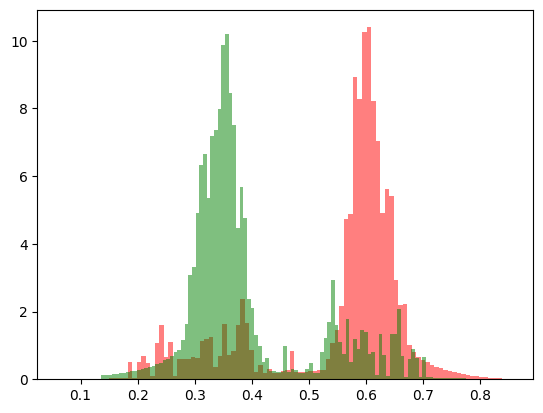

In [7]:
plt.hist(colour_clustered["A_R"], 100, density=True, alpha=0.5, color="red")
plt.hist(colour_clustered["A_G"], 100, density=True, alpha=0.5, color="green")
# plt.hist(colour_clustered['A_B'], 1000, density=True, alpha=0.5, color='blue');
plt.show()

In [ ]:
def gaussian_pdf(x, mu, sigma):
    A = np.exp(-0.5 * (x - mu) ** 2 / sigma**2)
    return np.squeeze(A / np.max(A))

In [ ]:
x = np.linspace(0, 1, 1000)

In [ ]:
fig, axs = plotter.one_column_plot()

axs.hist(new_data["A_R"], 1000, density=True, alpha=0.5, color="red")
axs.hist(new_data["A_G"], 1000, density=True, alpha=0.5, color="green")
axs.hist(new_data["A_B"], 1000, density=True, alpha=0.5, color="blue")

# plt.vlines(x=gmm.means_[0, :], ymax=4, ymin=0, color='red')
# plt.plot(x, 4*gaussian_pdf(x, gmm.means_[1, 0], np.sqrt(gmm.covariances_[1][0,0])), 'red')
# plt.plot(x, 0.5*gaussian_pdf(x, gmm.means_[1, 1], np.sqrt(gmm.covariances_[1][1,1])), 'red')

# plt.plot(x, 0.5*gaussian_pdf(x, gmm.means_[1], np.sqrt(gmm.covariances_[1])))
# plt.plot(x, 0.78870981*gaussian_pdf(x, gmm.means_[0], np.sqrt(gmm.covariances_[0])) + 0.21129019*gaussian_pdf(x, gmm.means_[1], np.sqrt(gmm.covariances_[1])))
axs.set_ylim([0, 15])
axs.set_xlim([0, 1])

axs.set_xlabel("colour fraction")
axs.set_ylabel("probability density")

# plt.savefig('Colours_of_Localisations.svg', dpi=600, format='svg')
plt.show()

In [ ]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1, 1], height=6)


axs[0].hist(new_data["A_R"], 1000, density=True, alpha=0.5, color="red")
axs[0].hist(new_data["A_G"], 1000, density=True, alpha=0.5, color="green")
axs[0].hist(new_data["A_B"], 1000, density=True, alpha=0.5, color="blue")

axs[1].hist(colour_clustered["A_R"], 100, density=True, alpha=0.5, color="red")
axs[1].hist(colour_clustered["A_G"], 100, density=True, alpha=0.5, color="green")
axs[1].hist(colour_clustered["A_B"], 100, density=True, alpha=0.5, color="blue")

# plt.vlines(x=gmm.means_[0, :], ymax=4, ymin=0, color='red')
# plt.plot(x, 4*gaussian_pdf(x, gmm.means_[1, 0], np.sqrt(gmm.covariances_[1][0,0])), 'red')
# plt.plot(x, 0.5*gaussian_pdf(x, gmm.means_[1, 1], np.sqrt(gmm.covariances_[1][1,1])), 'red')

# plt.plot(x, 0.5*gaussian_pdf(x, gmm.means_[1], np.sqrt(gmm.covariances_[1])))
# plt.plot(x, 0.78870981*gaussian_pdf(x, gmm.means_[0], np.sqrt(gmm.covariances_[0])) + 0.21129019*gaussian_pdf(x, gmm.means_[1], np.sqrt(gmm.covariances_[1])))
axs[1].set_ylim([0, 40])
axs[1].set_xlim([0, 1])

for i in np.arange(2):
    axs[i].set_xlabel("colour fraction")
    axs[i].set_ylabel("probability density")

plt.savefig("Colours_of_Molecules_Comparison.svg", dpi=600, format="svg")
plt.show()

In [ ]:
import matplotlib as mpl

colors = ["navy", "turquoise"]


def make_ellipses(gmm, ax):
    for n, color in enumerate(colors):
        if gmm.covariance_type == "full":
            covariances = gmm.covariances_[n]
        elif gmm.covariance_type == "tied":
            covariances = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == "diag":
            covariances = np.diag(gmm.covariances_[n][:2])
        elif gmm.covariance_type == "spherical":
            covariances = np.eye(gmm.means_.shape[1]) * gmm.covariances_[n]
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi  # convert to degrees
        v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
        ell = mpl.patches.Ellipse(
            gmm.means_[n, :2], v[0], v[1], angle=180 + angle, color=color
        )
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.5)
        ax.add_artist(ell)
        ax.set_aspect("equal", "datalim")

In [ ]:
X = np.vstack([new_data["A_G"], new_data["A_R"]]).T

estimator = mixture.GaussianMixture(
    n_components=2,
    covariance_type="full",
)


# Since we have class labels for the training data, we can
# initialize the GMM parameters in a supervised manner.

# Train the other parameters using the EM algorithm.
fig, h = plotter.one_column_plot(width=6, height=6)

estimator.fit(X)
make_ellipses(estimator, h)

xvals = np.random.randint(low=0, high=len(new_data), size=10000)
h.scatter(
    new_data["A_G"].to_numpy()[xvals],
    new_data["A_R"].to_numpy()[xvals],
    s=1,
    alpha=0.1,
    color="gray",
)


h.set_xlim([0, 1])
h.set_ylim([0, 1])
plt.xlabel("G")
plt.ylabel("R")
plt.show()

In [ ]:
X = np.vstack([colour_clustered["A_G"], colour_clustered["A_R"]]).T

In [ ]:
cluster_vals = estimator.predict(X)

In [ ]:
colour_clustered["cluster_vals"] = cluster_vals
IO._write_h5_database(
    filepath=os.path.join(
        image_folder, "Undrifted_GaussFiltered_Locs_colour_clustered.h5"
    ),
    df=colour_clustered,
)

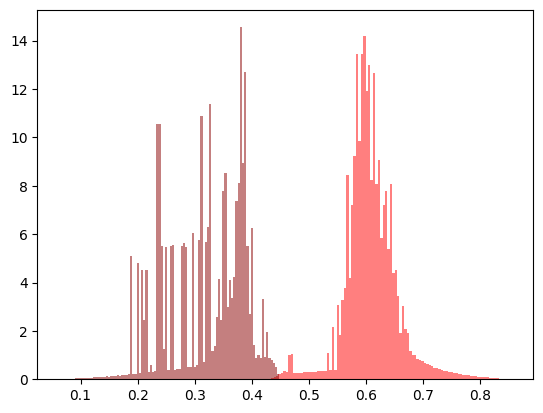

In [8]:
cluster_1 = colour_clustered[colour_clustered["cluster_vals"] == 0]["A_R"]
plt.hist(cluster_1, 100, density=True, alpha=0.5, color="red")
cluster_2 = colour_clustered[colour_clustered["cluster_vals"] == 1]["A_R"]
plt.hist(cluster_2, 100, density=True, alpha=0.5, color="darkred");

In [369]:
NR_Locs = colour_clustered[colour_clustered["cluster_vals"] == 0]
NR_Locs = NR_Locs[NR_Locs["A_R"] < 0.7]
NR_Locs = NR_Locs[NR_Locs["A_R"] > 0.55]

n_locs, image_NR, image_NR_spectral = render.render(
    locs=NR_Locs.to_records(index=False),
    oversampling=8,
    viewport=((0, 0), (height, width)),
    blur_method="gaussian_colour",
    c_max=0.75,
    c_min=0.3,
    densitymin=0.05,
)

In [260]:
np.array(image_NR.shape) / 8 * 0.069

array([ 77.832,  64.86 ])

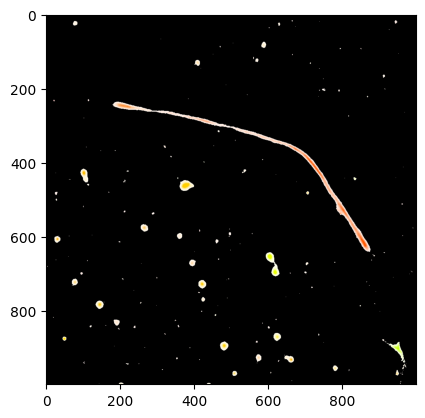

In [309]:
plt.imshow(
    np.rot90(
        image_NR_spectral[start_x : start_x + iwidth, start_y : start_y + iwidth, :]
    )
)

In [310]:
import skimage
from skimage.filters import threshold_li

In [376]:
th = skimage.filters.threshold_li(image_NR)

In [377]:
th_image = np.zeros_like(image_NR)
th_image[image_NR > th] = 1

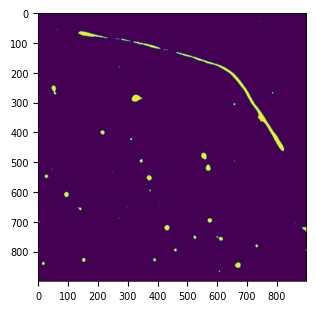

In [378]:
plt.imshow(np.rot90(th_image[start_x : start_x + iwidth, start_y : start_y + iwidth]))

In [379]:
skimage.measure.regionprops

<function skimage.measure._regionprops.regionprops(label_image, intensity_image=None, cache=True, *, extra_properties=None, spacing=None, offset=None)>

In [380]:
from skimage.draw import ellipse
from skimage.measure import label, regionprops, regionprops_table
from skimage.transform import rotate

In [381]:
label_img = label(th_image)

In [382]:
def feature_extractor(label_img, localisations, pixel_size=0.069, oversampling=8):
    dict_sk = regionprops_table(
        label_img,
        spacing=(pixel_size / oversampling, pixel_size / oversampling),
        properties=(
            "area",
            "axis_major_length",
            "axis_minor_length",
            "bbox",
            "num_pixels",
        ),
    )
    R_values = np.zeros_like(dict_sk["axis_major_length"])
    G_values = np.zeros_like(dict_sk["axis_major_length"])
    B_values = np.zeros_like(dict_sk["axis_major_length"])
    photons = np.zeros_like(dict_sk["axis_major_length"])
    for i in np.arange(len(dict_sk["axis_major_length"])):
        min_x = dict_sk["bbox-1"][i] / oversampling
        min_y = dict_sk["bbox-0"][i] / oversampling
        max_x = dict_sk["bbox-3"][i] / oversampling
        max_y = dict_sk["bbox-2"][i] / oversampling
        subset = localisations[
            (localisations["xc"] > min_x)
            & (localisations["xc"] < max_x)
            & (localisations["yc"] > min_y)
            & (localisations["yc"] < max_y)
        ]
        R_values[i] = np.average(subset["A_R"])
        G_values[i] = np.average(subset["A_G"])
        B_values[i] = np.average(subset["A_B"])
        photons[i] = np.average(subset["photons"])
    dict_sk["R"] = R_values
    dict_sk["G"] = G_values
    dict_sk["B"] = B_values
    dict_sk["photons"] = photons
    return dict_sk

In [383]:
dict = feature_extractor(label_img, NR_Locs)

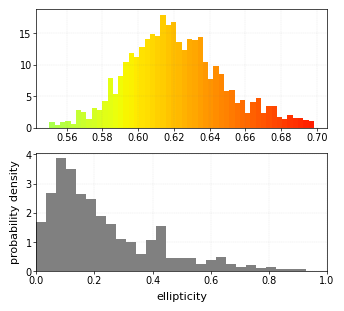

In [473]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1, 1], height=3)

from matplotlib.colors import Normalize
from matplotlib import cm

major_length = dict["axis_major_length"]
minor_length = dict["axis_minor_length"]

min_x = dict_sk["bbox-1"]
min_y = dict_sk["bbox-0"]
max_x = dict_sk["bbox-3"]
max_y = dict_sk["bbox-2"]

area = dict["area"]
num_pixels = dict["num_pixels"]
R_value = dict["R"]

filter = (major_length > 0) * (minor_length > 0) * ~np.isnan(R_value)
R = R_value[filter]
major_length = major_length[filter]
minor_length = minor_length[filter]
min_x = min_x[filter]
min_y = min_y[filter]
max_x = max_x[filter]
max_y = max_y[filter]

N, bins, patches = axs[0].hist(R, bins=np.histogram_bin_edges(R, "sqrt"), density=True)

norm = Normalize(0.3, 0.75)
# set a color for every bar (patch) according
# to bin value from normalized min-max interval
for bin, patch in zip(bins, patches):
    color = cm.jet(norm(bin))
    patch.set_facecolor(color)
axs[0].grid(True, which="both", ls="--", c="gray", lw=0.25, alpha=0.25)

e = (major_length - minor_length) / major_length

axs[1] = plotter.histogram_plot(
    axs[1], e, np.histogram_bin_edges(e, "fd"), xaxislabel="ellipticity"
)
axs[1].set_xlim([0, 1])

plt.savefig("asyn_NR_datapanels.svg", dpi=600, format="svg")
plt.show()

In [487]:
len(e)

2404

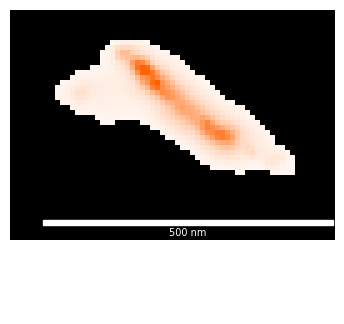

In [482]:
ind = 302
fig, axs = plotter.one_column_plot()
axs.imshow(
    np.rot90(
        image_NR_spectral[
            min_y[ind] - 20 : max_y[ind] + 10, min_x[ind] - 15 : max_x[ind] + 7, :
        ]
    )
)
axs.set_axis_off()

pixvals = 500 / (69 / 8)
scalebar = AnchoredSizeBar(
    axs.transData,
    pixvals,
    r"500 nm",
    "lower right",
    pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
)
axs.add_artist(scalebar)
axs.annotate(
    label,
    xy=(5, 5),
    xytext=(20, 60),
    xycoords="data",
    color="white",
    fontsize=6,
)
plt.savefig("asyn_colour0p66.svg", dpi=600, format="svg")

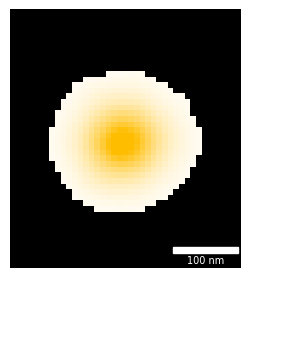

In [477]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

ind = 21
fig, axs = plotter.one_column_plot()
axs.imshow(
    np.rot90(
        image_NR_spectral[
            min_y[ind] - 10 : max_y[ind] + 10, min_x[ind] - 12 : max_x[ind] + 14, :
        ]
    )
)
axs.set_axis_off()

pixvals = 100 / (69 / 8)
scalebar = AnchoredSizeBar(
    axs.transData,
    pixvals,
    "100 nm",
    "lower right",
    pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
)
axs.add_artist(scalebar)
axs.annotate(
    label,
    xy=(5, 5),
    xytext=(20, 60),
    xycoords="data",
    color="white",
    fontsize=6,
)

plt.savefig("asyn_colour0p61.svg", dpi=600, format="svg")

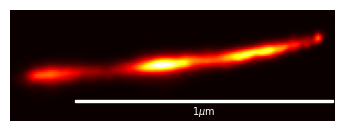

In [485]:
ind = 689
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs,
    np.rot90(
        image_NR[min_y[ind] - 5 : max_y[ind] + 5, min_x[ind] - 10 : max_x[ind] + 15]
    ),
    cmap="hot",
    pixelsize=69 / 8,
    scalebarsize=1000,
    scalebarlabel=r"1$\mu$m",
    cbar="off",
)
axs.set_axis_off()
plt.savefig("asyn_fibril.svg", dpi=600, format="svg")

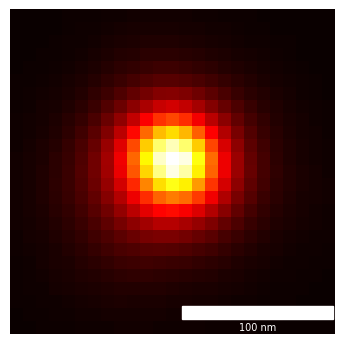

In [452]:
ind = 2
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs,
    np.rot90(image_NR[min_y[ind] : max_y[ind], min_x[ind] : max_x[ind]]),
    cmap="hot",
    pixelsize=69 / 8,
    scalebarsize=100,
    scalebarlabel=r"100 nm",
    cbar="off",
)
axs.set_axis_off()
plt.savefig("asyn_oligomer.svg", dpi=600, format="svg")

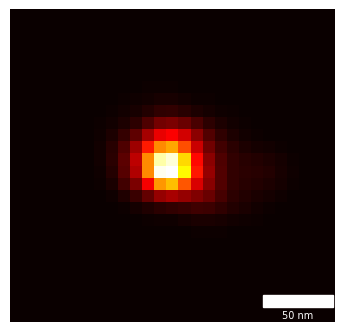

In [476]:
ind = 23
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs,
    np.rot90(
        image_NR[min_y[ind] - 10 : max_y[ind] + 10, min_x[ind] - 10 : max_x[ind] + 10]
    ),
    cmap="hot",
    pixelsize=69 / 8,
    scalebarsize=50,
    scalebarlabel=r"50 nm",
    cbar="off",
)
axs.set_axis_off()
plt.savefig("asyn_lowarea.svg", dpi=600, format="svg")

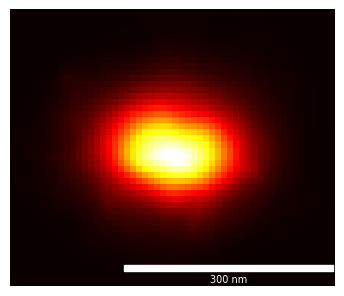

In [475]:
ind = 469
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs,
    np.rot90(
        image_NR[min_y[ind] - 10 : max_y[ind] + 10, min_x[ind] - 10 : max_x[ind] + 10]
    ),
    cmap="hot",
    pixelsize=69 / 8,
    scalebarsize=300,
    scalebarlabel=r"300 nm",
    cbar="off",
)
axs.set_axis_off()
plt.savefig("asyn_higharea.svg", dpi=600, format="svg")

In [ ]:
ind = 2
fig, axs = plotter.one_column_plot()
axs.imshow(
    np.rot90(image_NR[min_y[ind] : max_y[ind], min_x[ind] : max_x[ind]]), cmap="hot"
)
axs.set_axis_off()
plt.savefig("asyn_oligomer_eunder0p1.svg", dpi=600, format="svg")

41


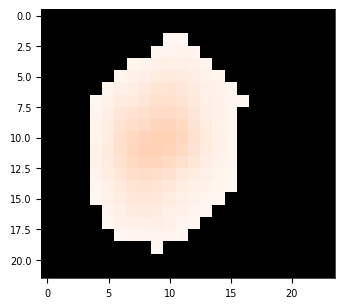

68


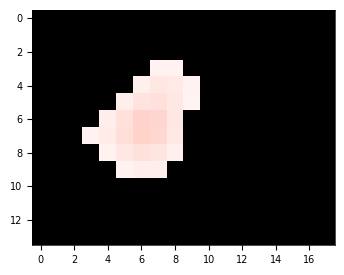

88


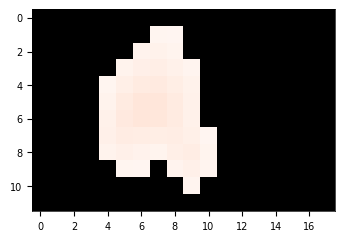

117


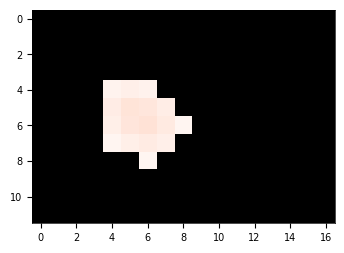

120


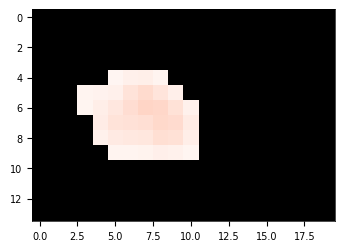

139


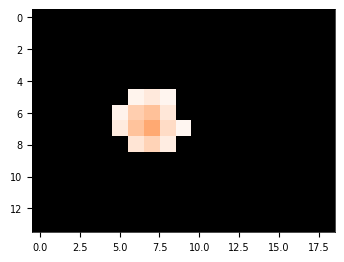

142


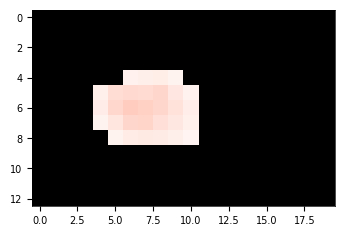

160


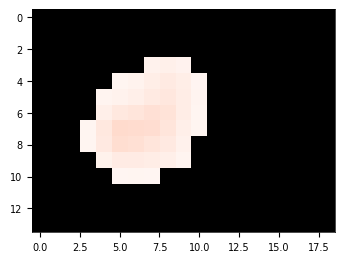

167


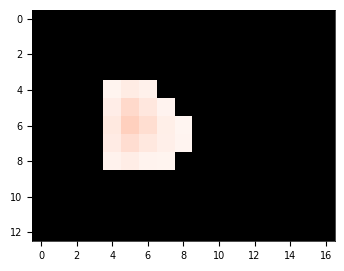

187


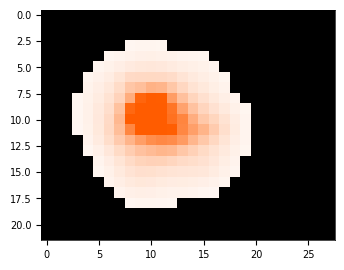

190


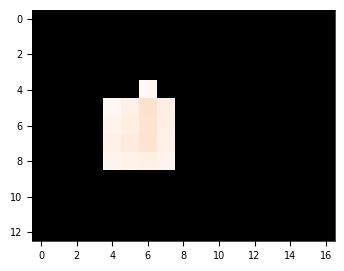

201


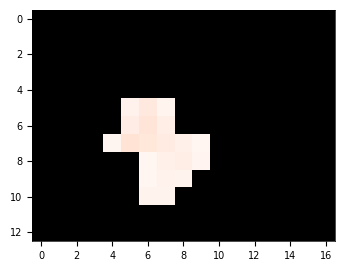

245


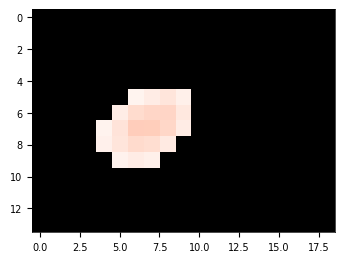

249


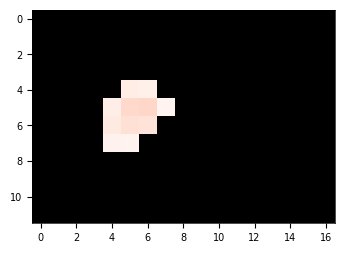

260


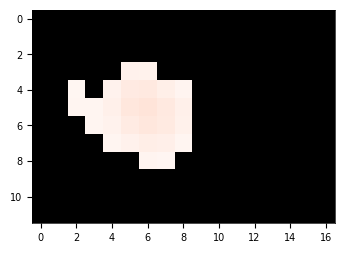

283


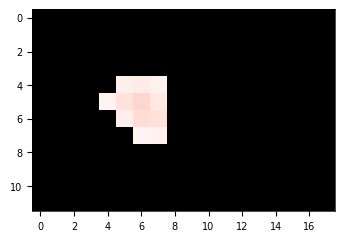

297


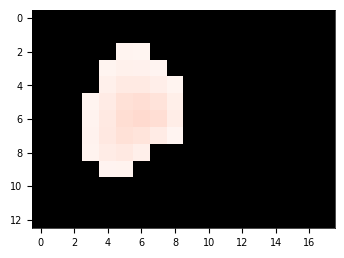

300


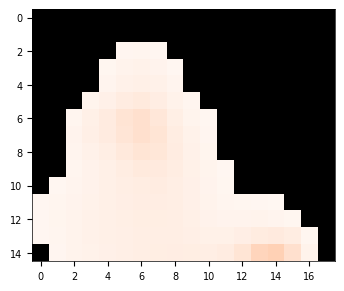

302


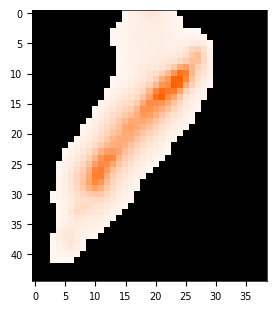

313


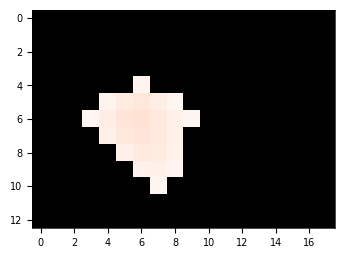

319


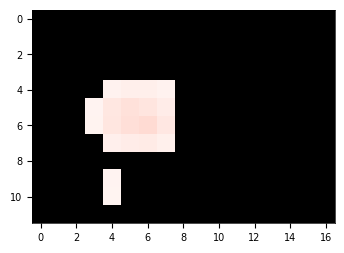

326


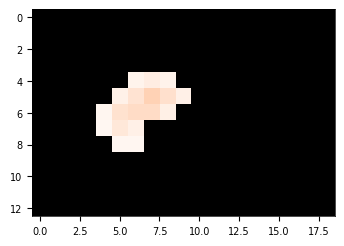

338


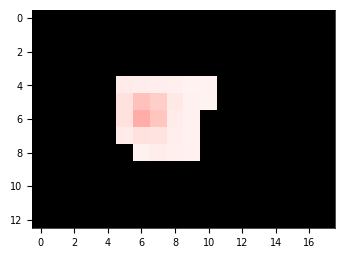

343


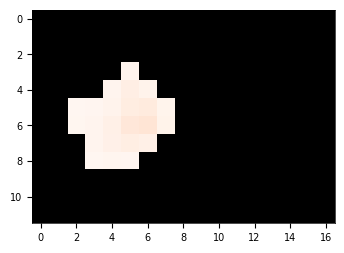

378


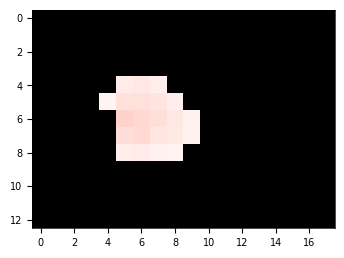

397


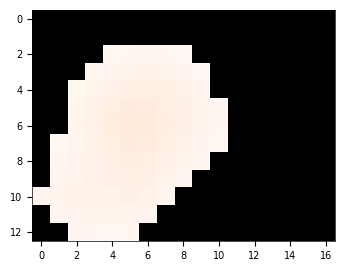

434


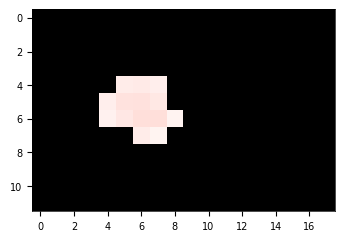

450


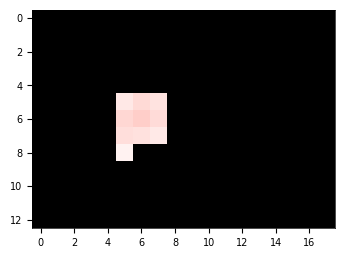

462


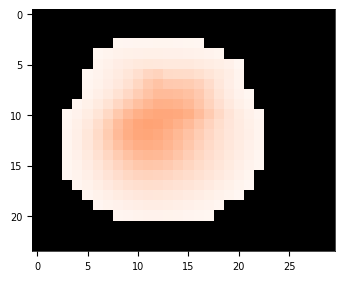

463


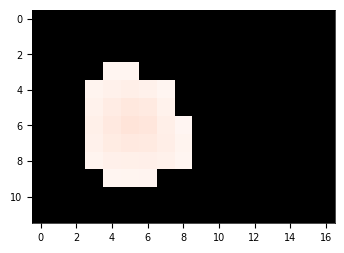

487


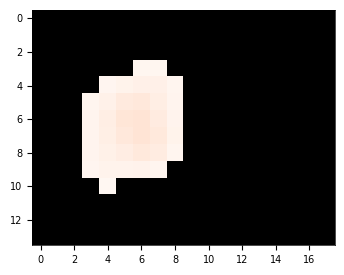

491


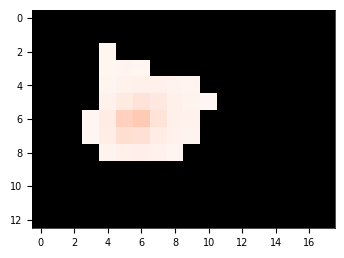

493


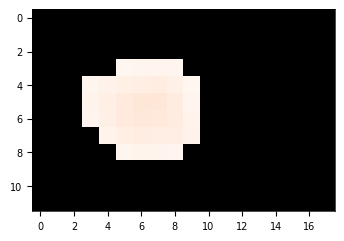

499


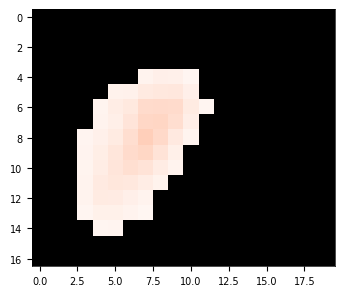

508


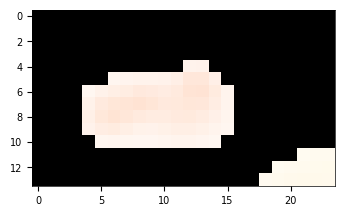

515


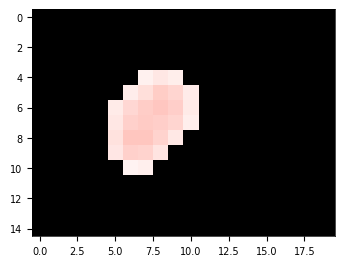

528


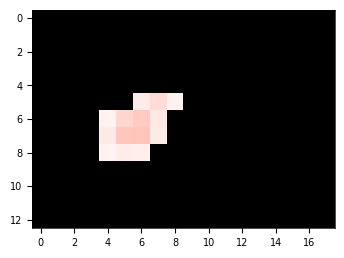

541


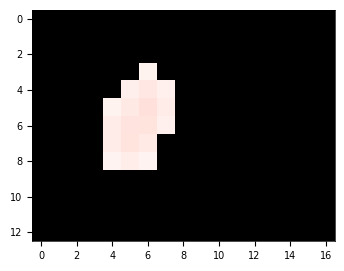

543


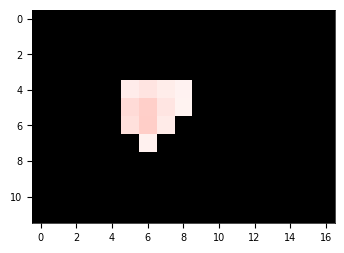

551


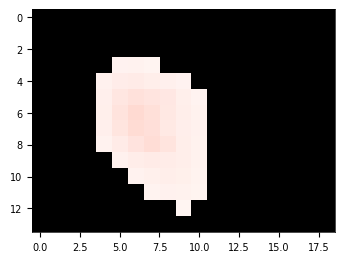

555


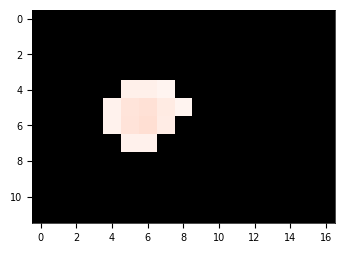

560


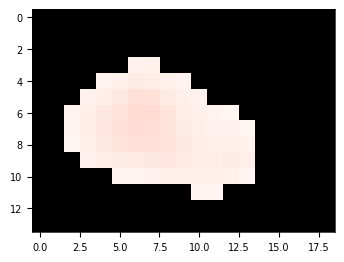

563


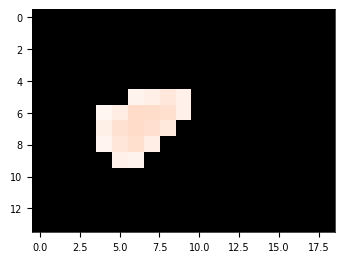

569


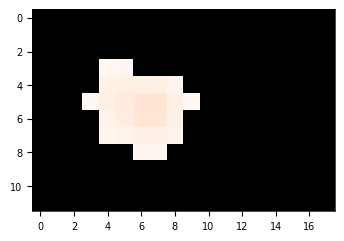

591


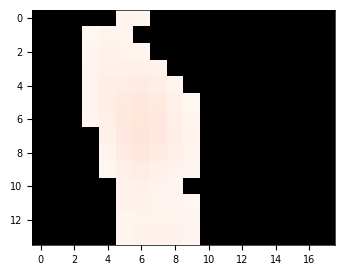

594


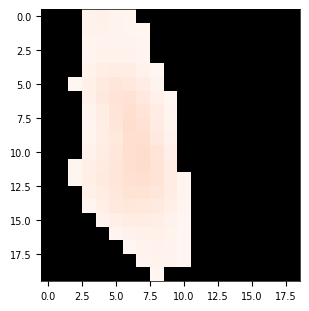

595


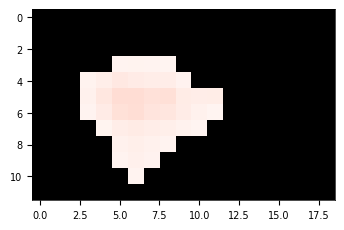

604


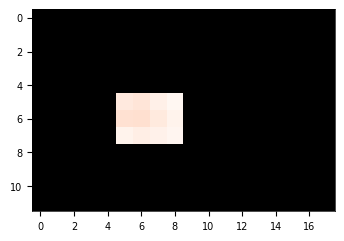

618


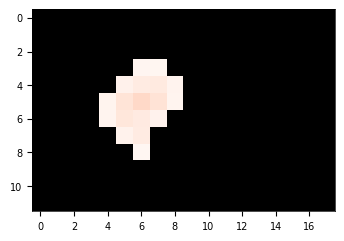

620


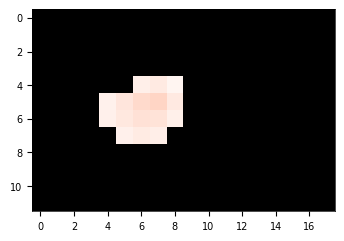

624


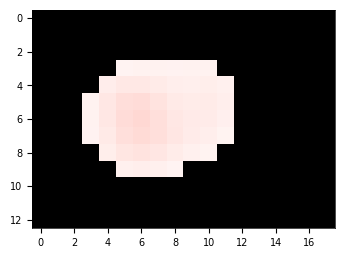

634


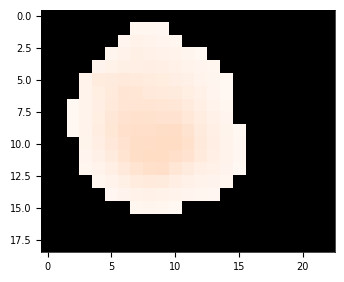

681


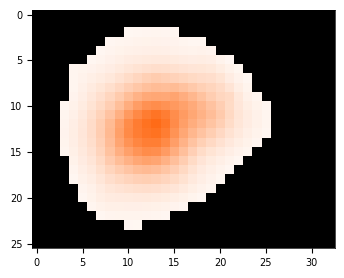

715


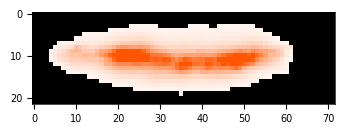

718


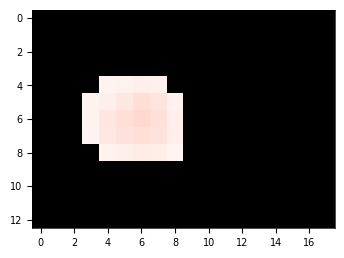

724


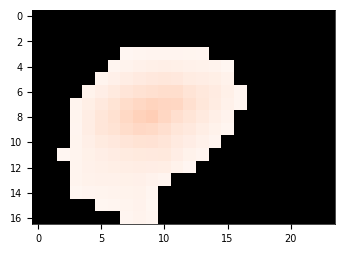

747


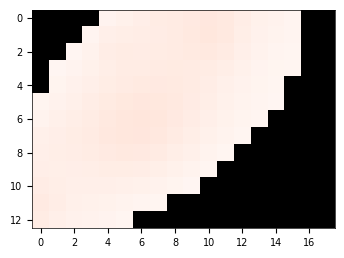

755


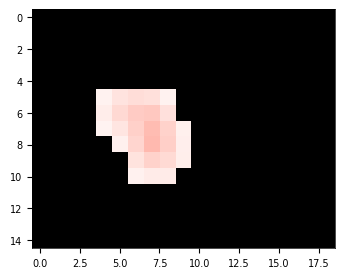

757


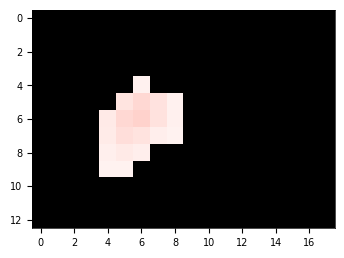

774


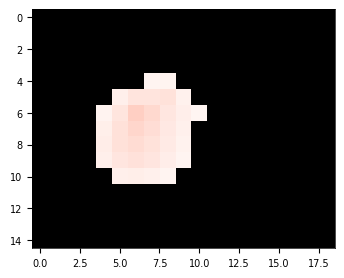

800


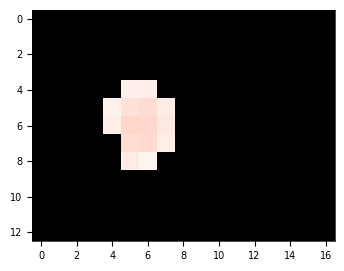

810


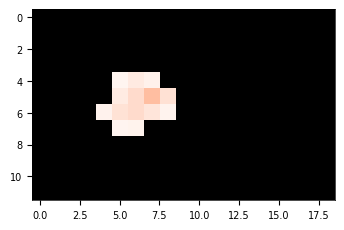

817


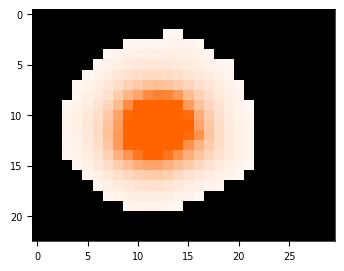

825


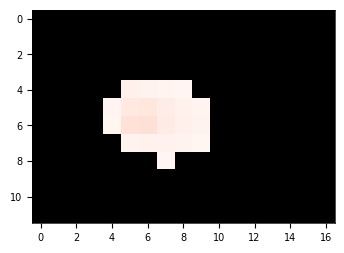

851


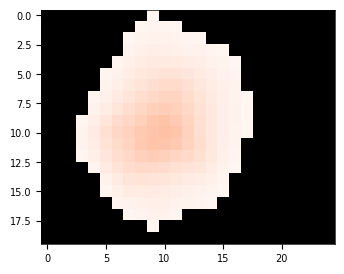

882


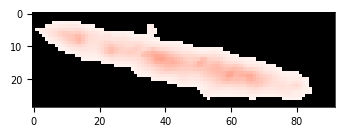

896


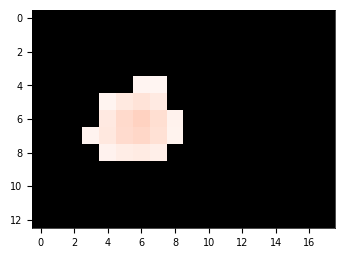

906


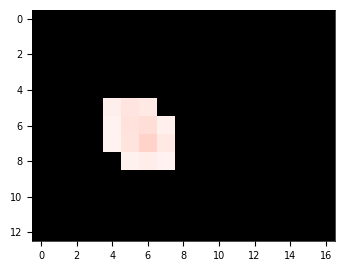

909


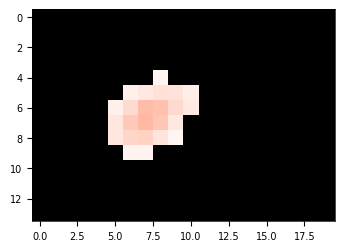

910


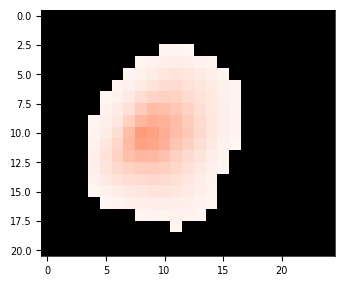

930


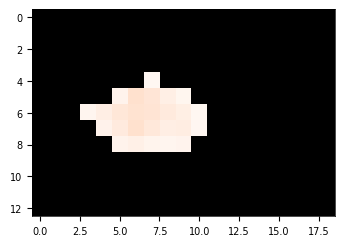

933


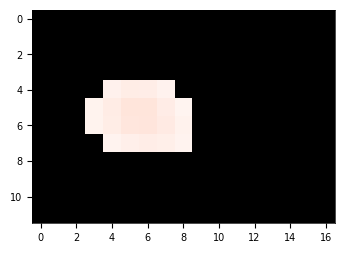

943


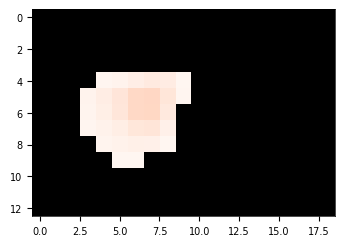

956


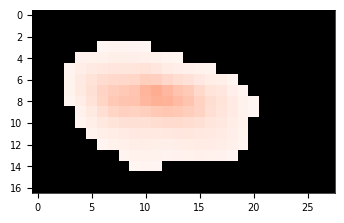

960


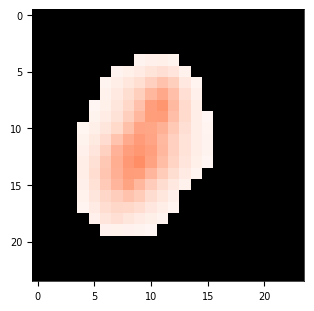

977


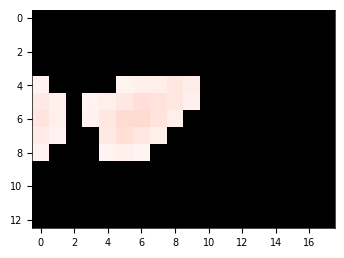

983


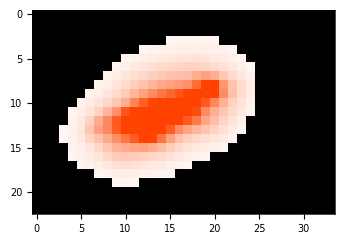

996


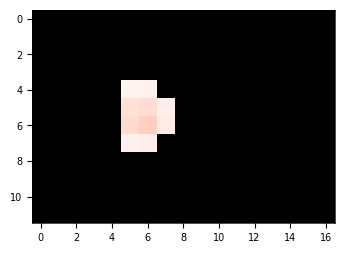

1006


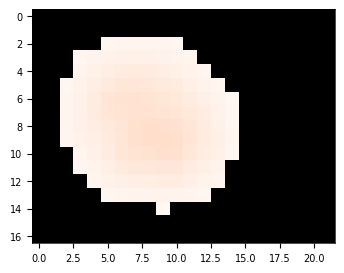

1016


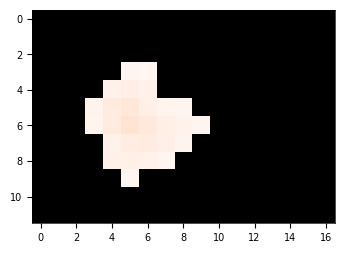

1023


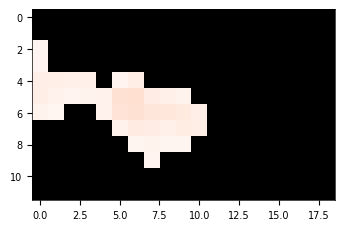

1030


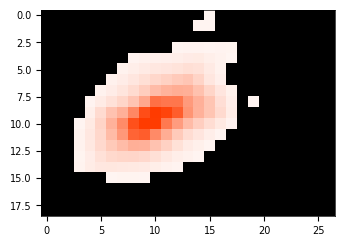

1037


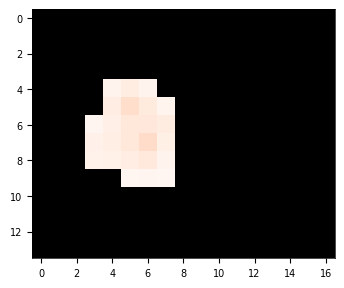

1093


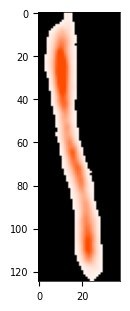

1103


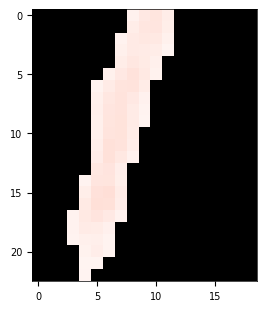

1114


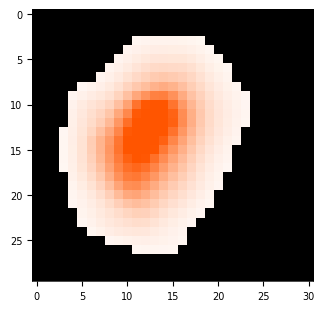

1128


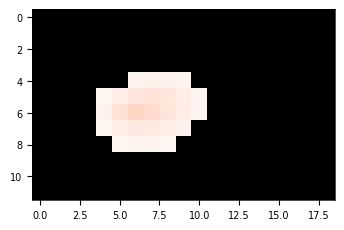

1131


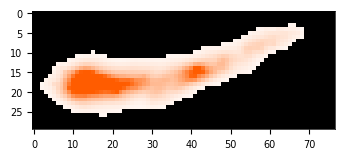

1141


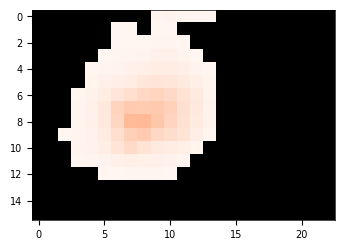

1145


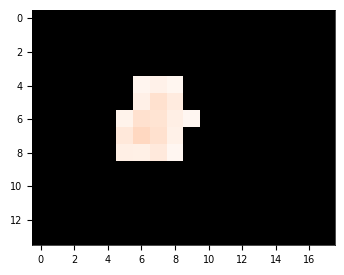

1149


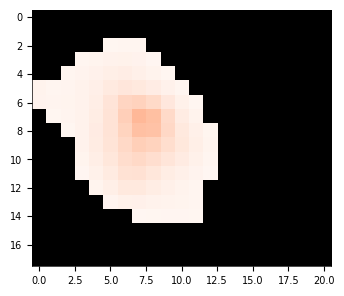

1153


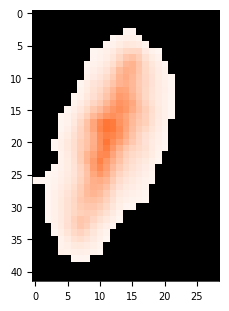

1192


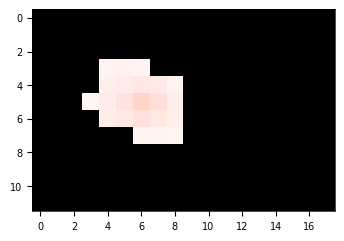

1193


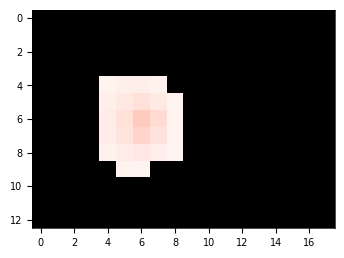

1200


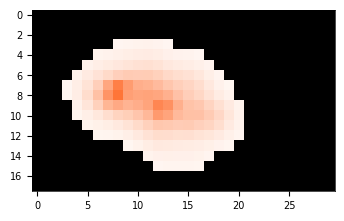

1213


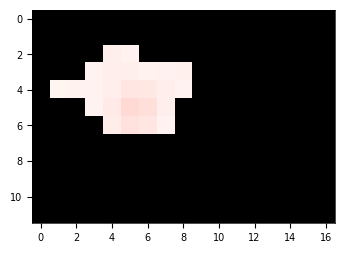

1220


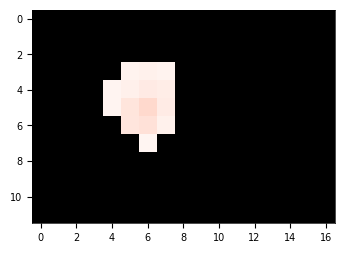

1221


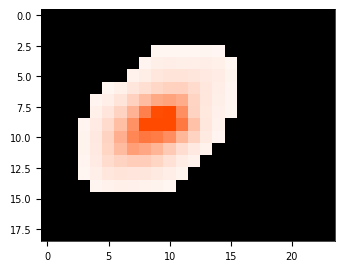

1225


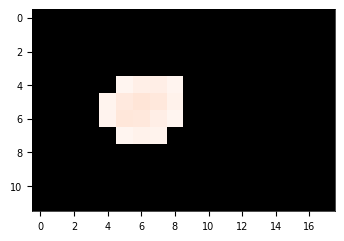

1269


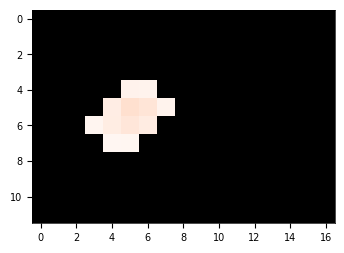

1272


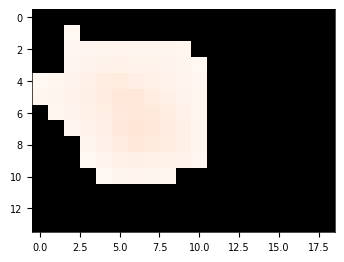

1298


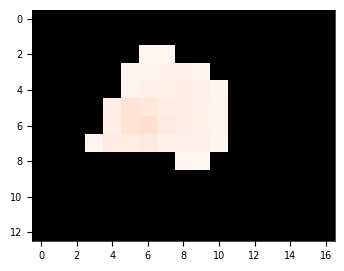

1303


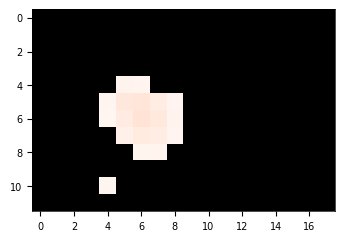

1321


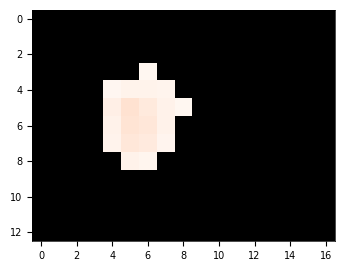

1326


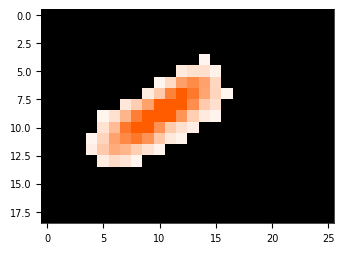

1361


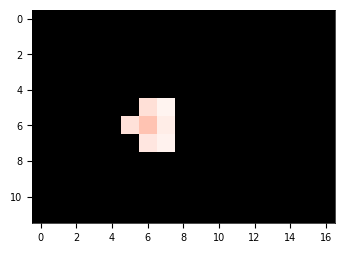

1371


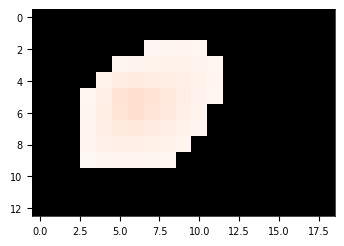

1386


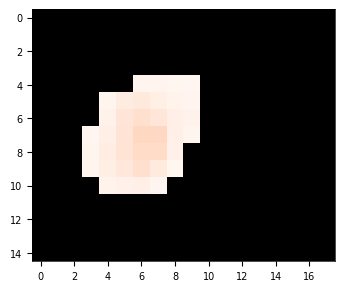

1407


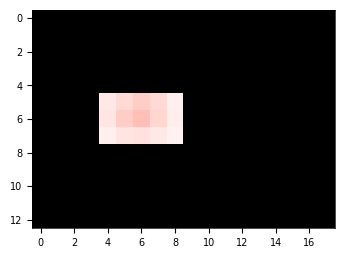

1418


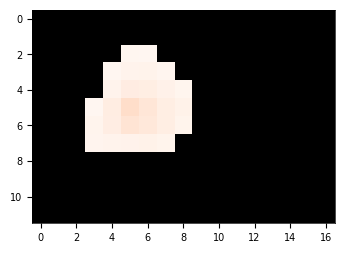

1419


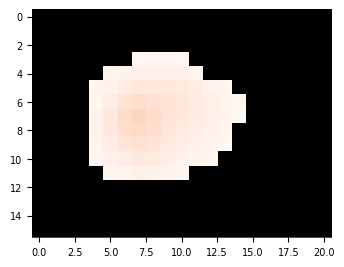

1420


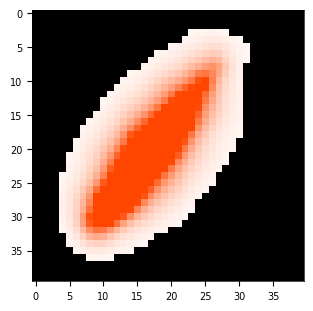

1421


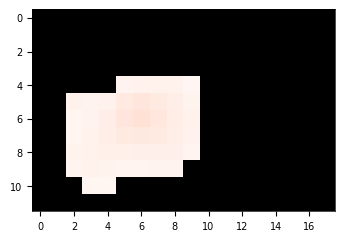

1449


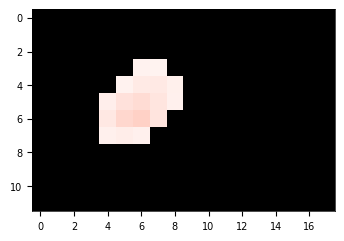

1454


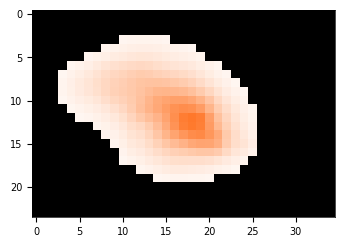

1464


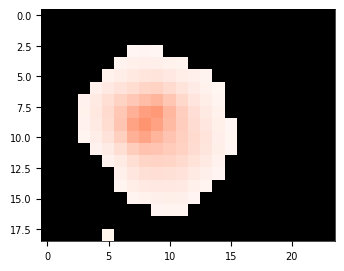

1472


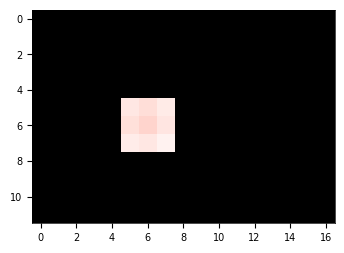

1481


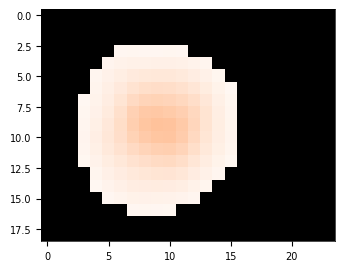

1489


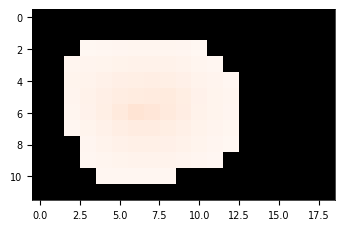

1493


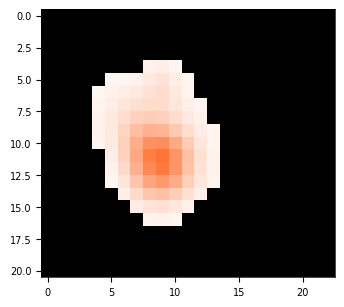

1506


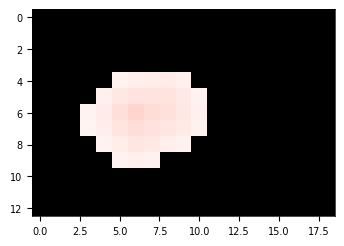

1514


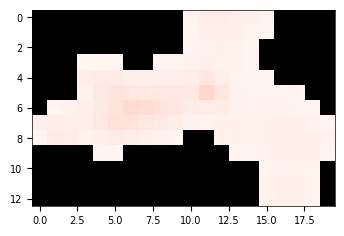

1524


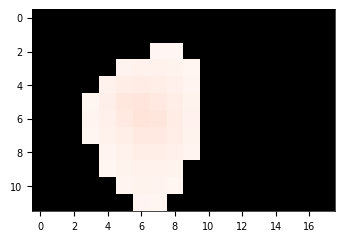

1528


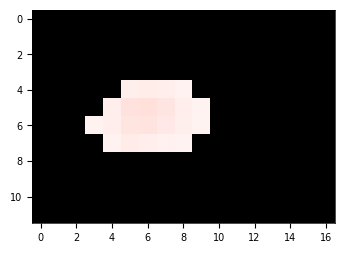

1545


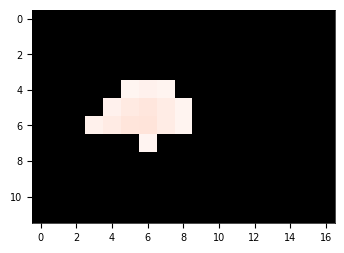

1554


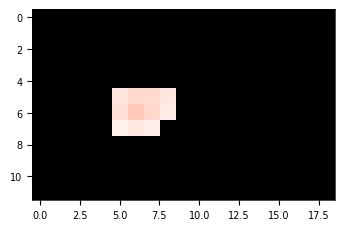

1569


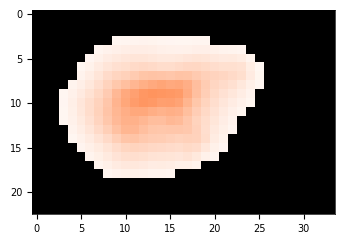

1593


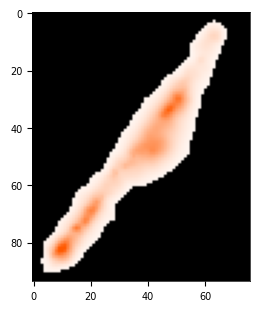

1596


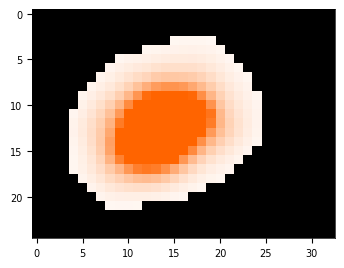

1598


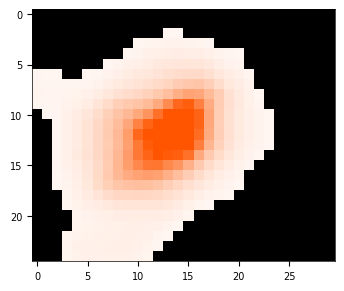

1599


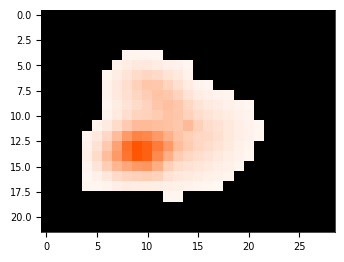

1604


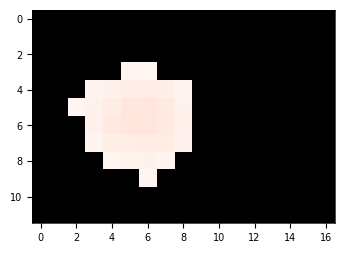

1633


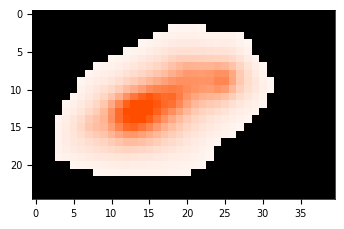

1649


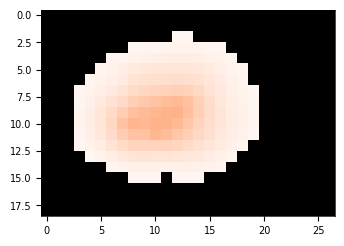

1656


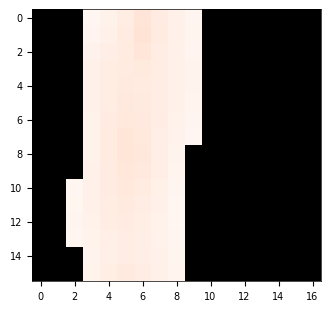

1663


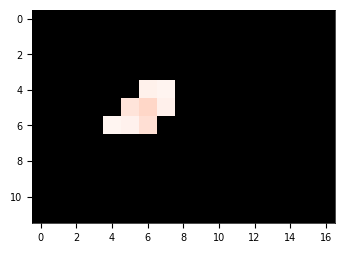

1666


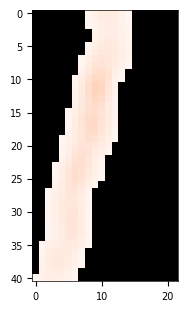

1678


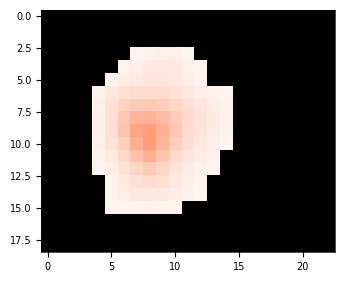

1679


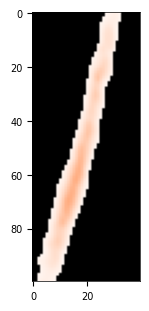

1688


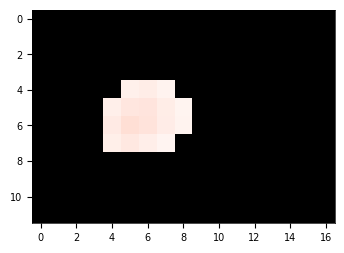

1708


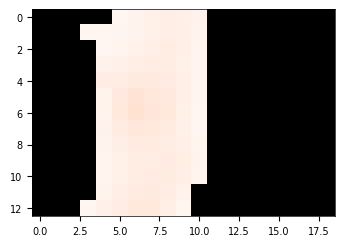

1710


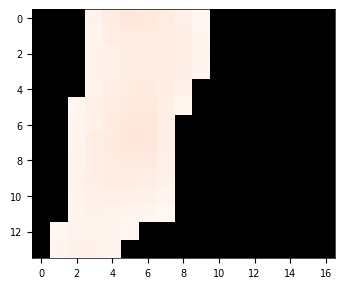

1715


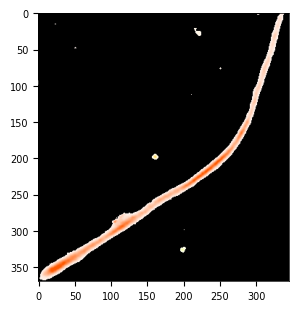

1734


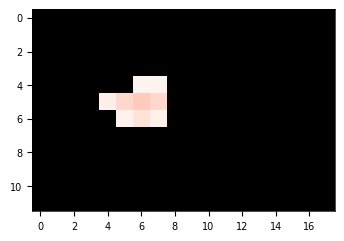

1760


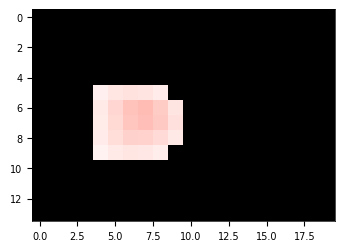

1791


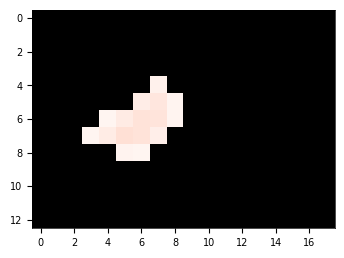

1798


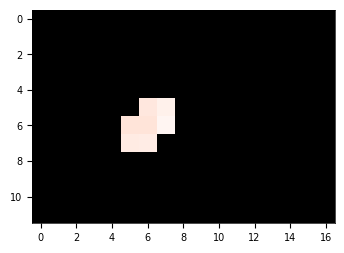

1799


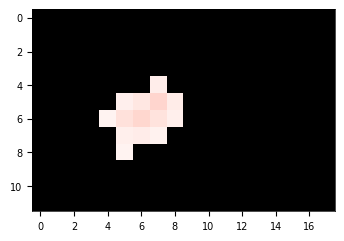

1809


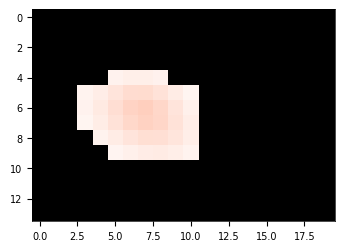

1813


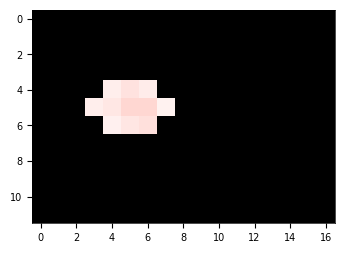

1833


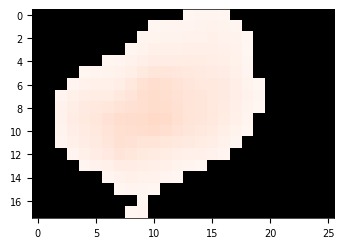

1846


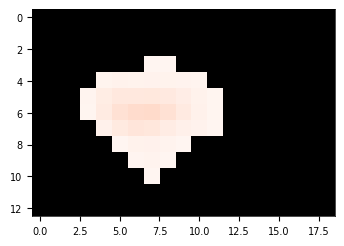

1856


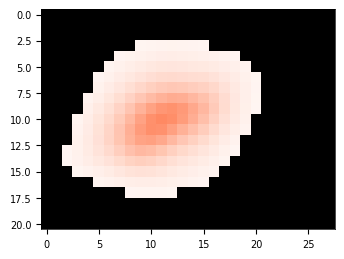

1857


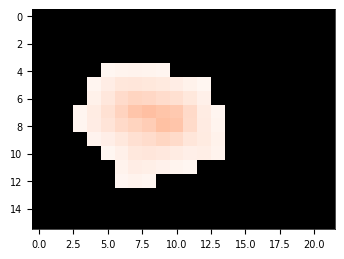

1866


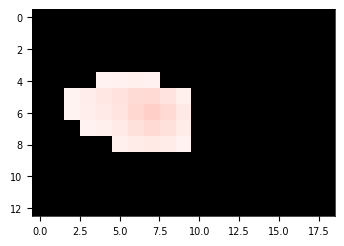

1873


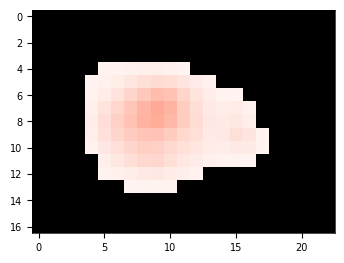

1877


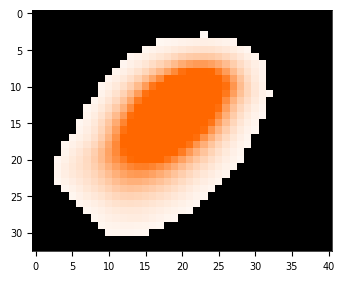

1885


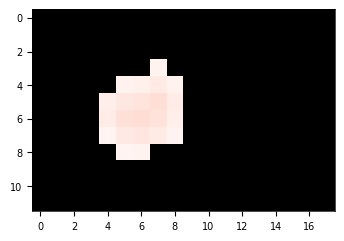

1894


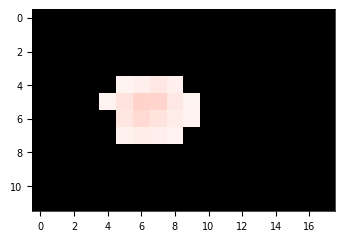

1903


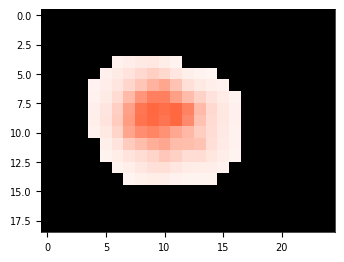

1924


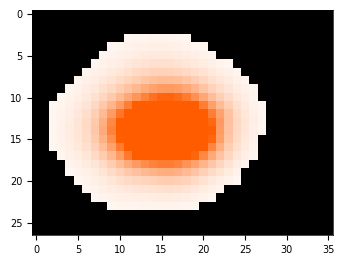

1934


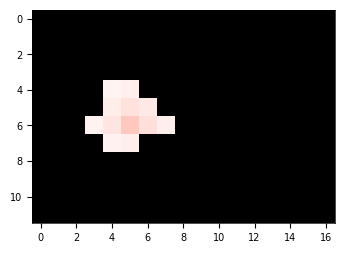

1941


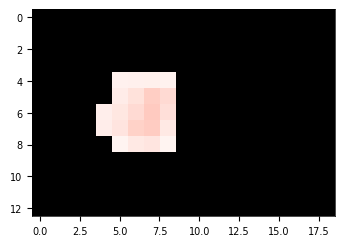

1942


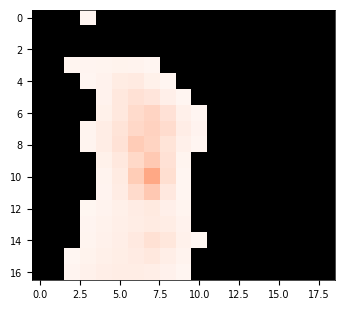

1943


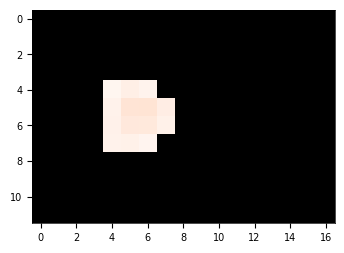

1946


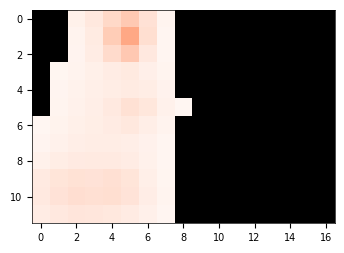

1948


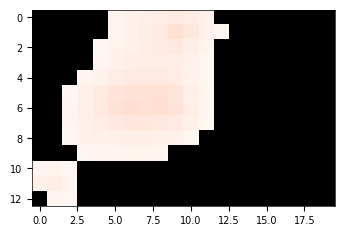

1958


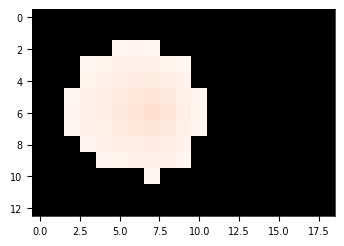

1960


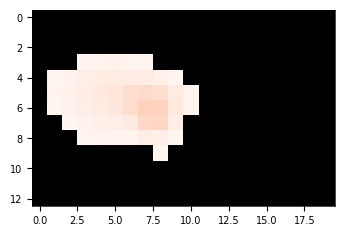

1961


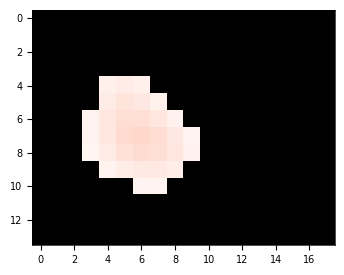

1962


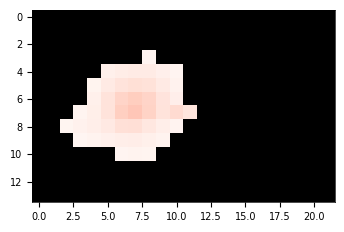

1971


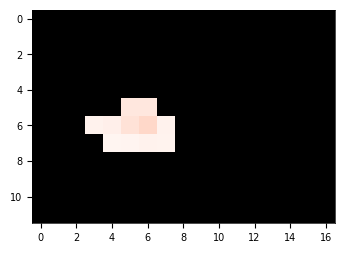

1976


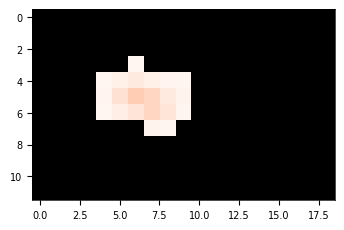

1986


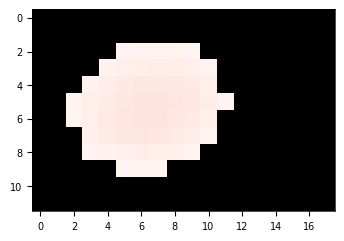

1993


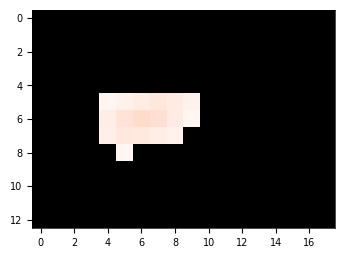

1999


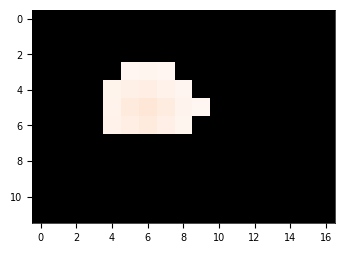

2000


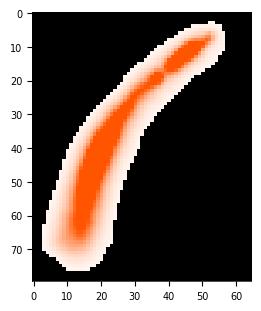

2004


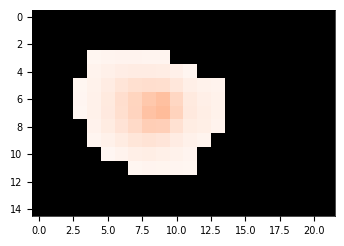

2008


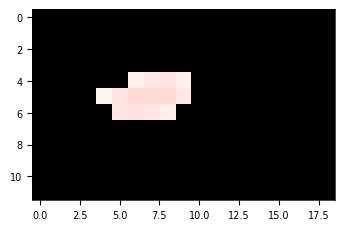

2013


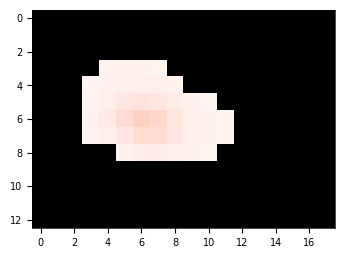

2017


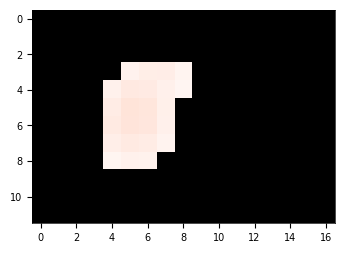

2035


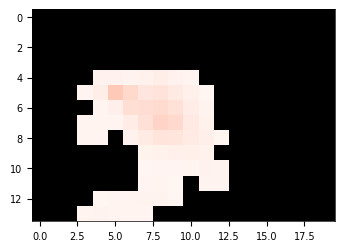

2046


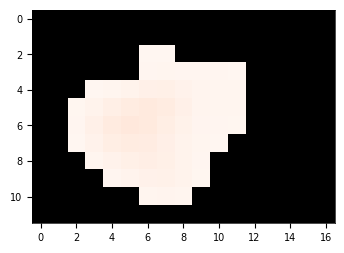

2049


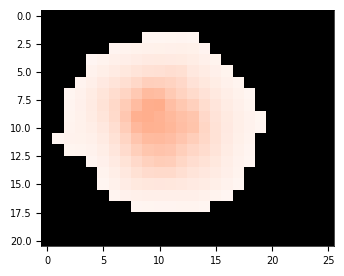

2061


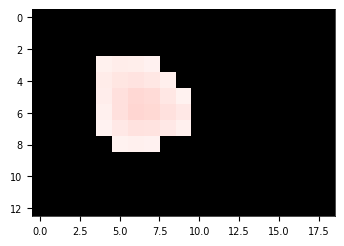

2066


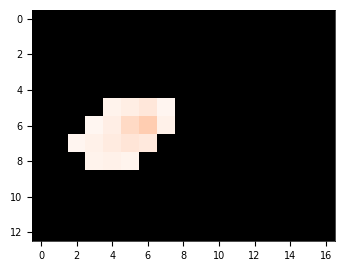

2069


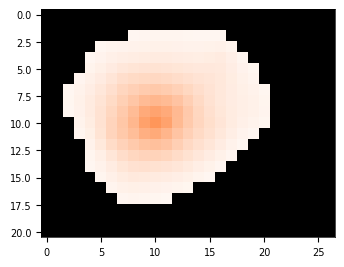

2077


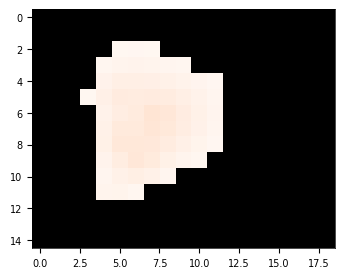

2095


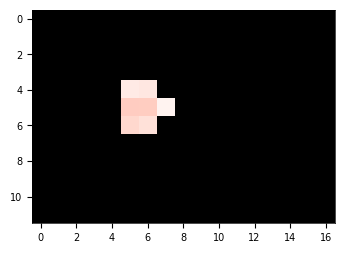

2097


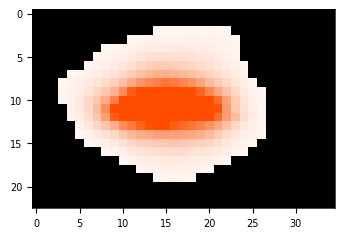

2130


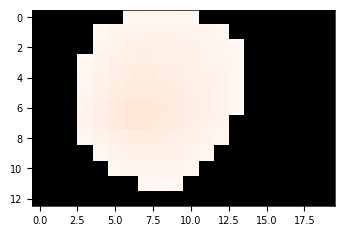

2141


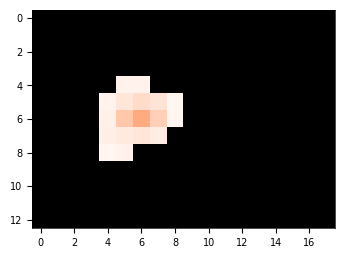

2148


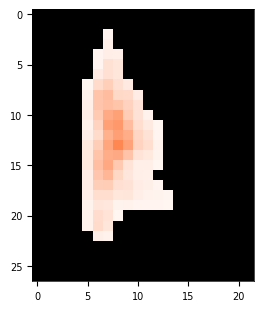

2178


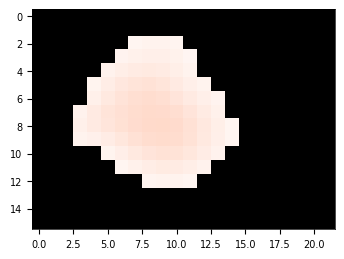

2199


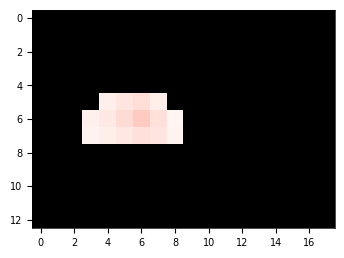

2204


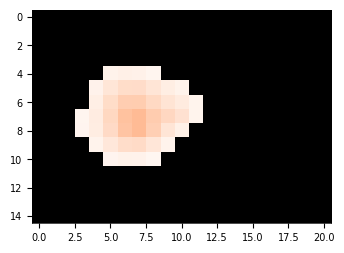

2205


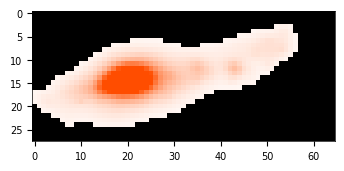

2210


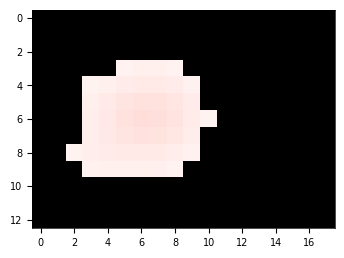

2228


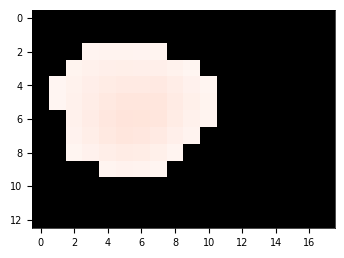

2231


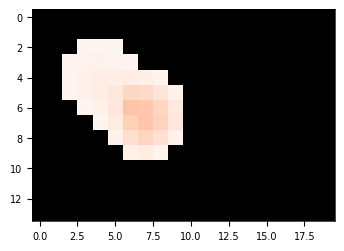

2244


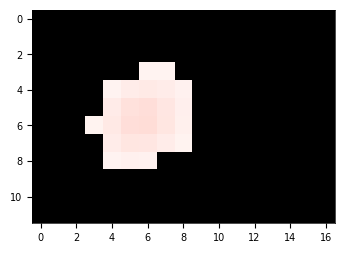

2248


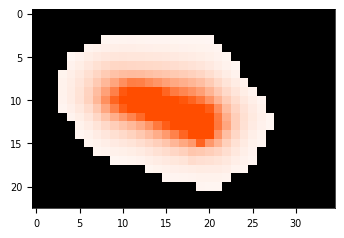

2249


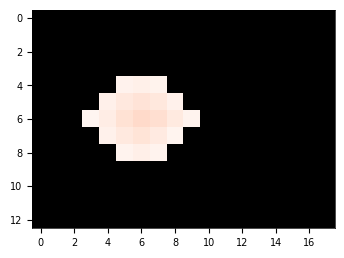

2253


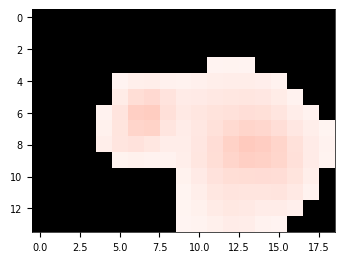

2255


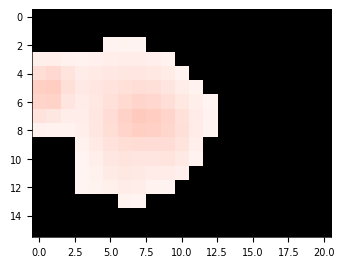

2258


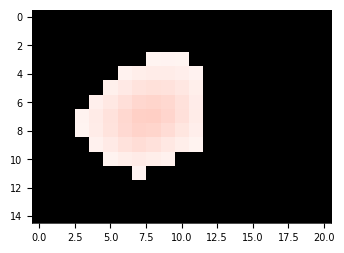

2287


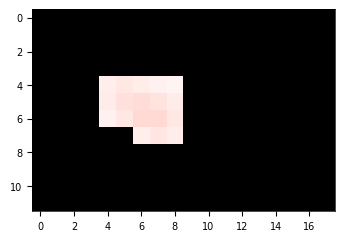

2290


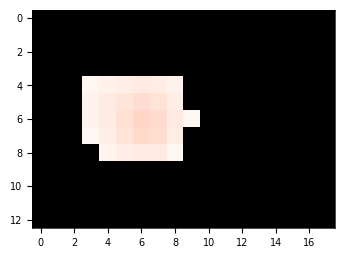

2298


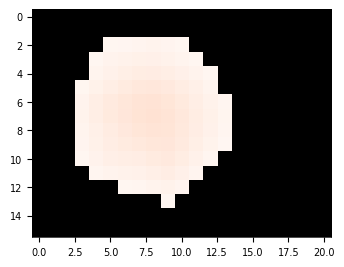

2302


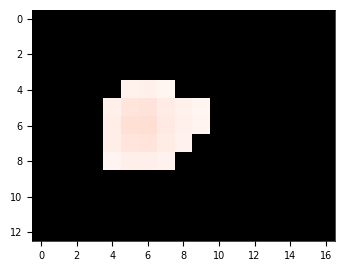

2308


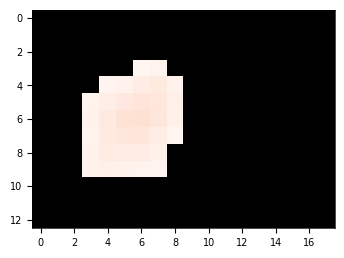

2311


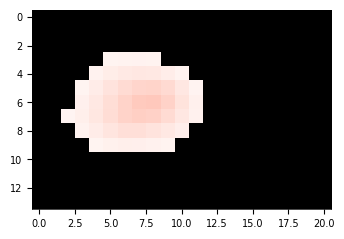

2325


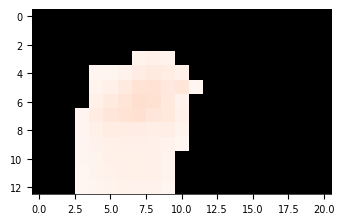

2339


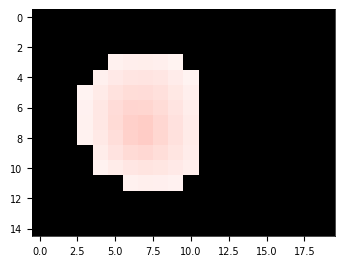

2378


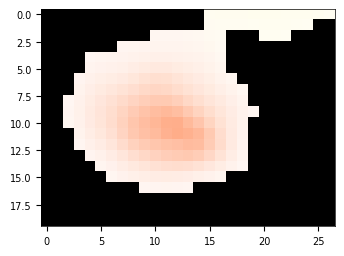

2382


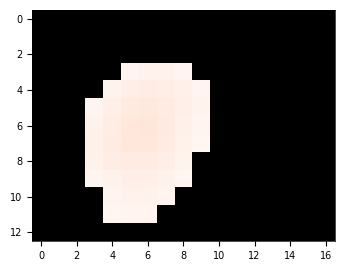

2385


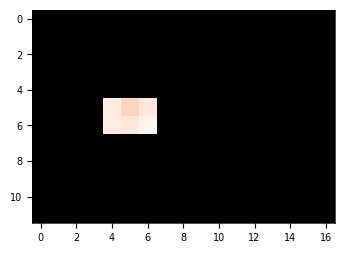

2389


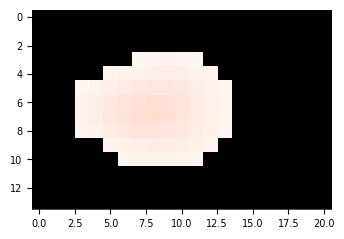

2402


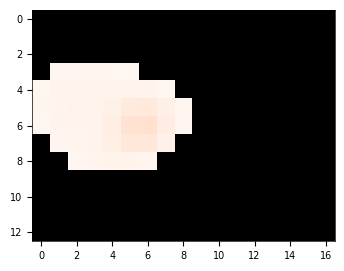

In [474]:
inds = np.where(R > 0.66)[0]
for ind in inds:
    print(ind)
    plt.imshow(
        image_NR_spectral[
            min_y[ind] - 5 : max_y[ind] + 5, min_x[ind] - 5 : max_x[ind] + 10, :
        ]
    )
    plt.show()
    time.sleep(1)

In [ ]:
plt.imshow(image_NR_spectral[5750:6750, 5000:6000, :])
plt.axis("off")
plt.show()

In [ ]:
plt.imshow(rgb_image[5750:6750, 5000:6000, :])

In [14]:
iwidth = 1000
start_x = 5750
start_y = 5000
oversampling = 8

subset = NR_Locs[
    (NR_Locs["xc"] > start_x / oversampling)
    & (NR_Locs["xc"] < (start_x + iwidth) / oversampling)
]
subset = subset[
    (subset["yc"] > start_y / oversampling)
    & (subset["yc"] < (start_y + iwidth) / oversampling)
]
subset = subset[subset["A_R_err"] < 0.05]

In [67]:
np.max(subset["A_R_err"])

0.0499827

In [71]:
X = np.vstack([subset["xc"], subset["yc"]]).T
loc_precision = 0.5 * (np.mean(subset["xc_err"]) + np.mean(subset["yc_err"]))
db_clusters = DBSCAN(min_samples=1, eps=loc_precision)
db_clusters.fit(X)

DBSCAN(eps=0.20734040439128876, min_samples=1)

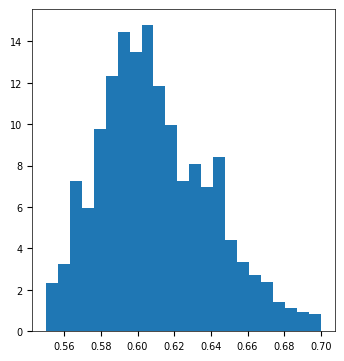

In [100]:
plt.hist(
    NR_Locs["A_R"], np.histogram_bin_edges(NR_Locs["A_R"], "sturges"), density=True
)
plt.show()

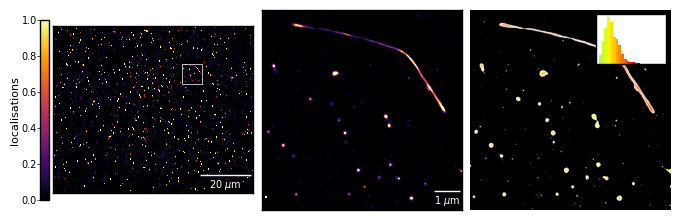

In [357]:
fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1, 1, 1])

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

iwidth = 900
start_x = 5800
start_y = 4925
axs[0] = plotter.image_plot(
    axs[0],
    image_NR.T,
    pixelsize=69 / 8,
    cbarlabel="localisations",
    cmap="inferno",
    scalebarsize=20000,
    scalebarlabel=r"20 $\mu$m",
    vmax=1,
)

import matplotlib.patches as patches

oversampling = 8
rect = patches.Rectangle(
    (start_x, start_y),
    iwidth,
    iwidth,
    linewidth=0.5,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs[0].add_patch(rect)


axs[1] = plotter.image_plot(
    axs[1],
    image_NR[start_x : start_x + iwidth, start_y : start_y + iwidth].T,
    pixelsize=69 / 8,
    vmax=5,
    cbar="off",
    cmap="inferno",
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)

axs[2].imshow(
    np.rot90(
        image_NR_spectral[start_x : start_x + iwidth, start_y : start_y + iwidth, :]
    )
)
axs[2].set_axis_off()

from matplotlib.colors import Normalize
from matplotlib import cm

axins = inset_axes(axs[2], width=0.7, height=0.5)
N, bins, patches = axins.hist(
    NR_Locs["A_R"], bins=np.histogram_bin_edges(NR_Locs["A_R"], "sturges"), density=True
)

norm = Normalize(0.3, 0.75)
# set a color for every bar (patch) according
# to bin value from normalized min-max interval
for bin, patch in zip(bins, patches):
    color = cm.jet(norm(bin))
    patch.set_facecolor(color)

plt.savefig("asyn_NR_SpectralInfo_redopanel1.svg", dpi=600, format="svg")
plt.show()

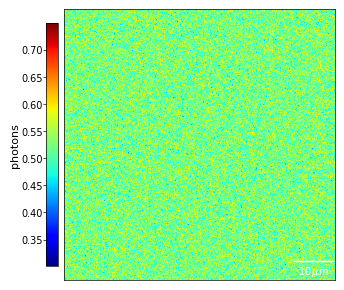

In [80]:
fig, axs = plotter.one_column_plot()

A = np.random.uniform(low=0.3, high=0.75, size=(1000, 1000))

axs = plotter.image_plot(axs, A, cmap="jet")

plt.savefig("jet_colourbar.svg", dpi=600, format="svg")

plt.show()

In [ ]:
X = np.vstack(
    [
        colour_clustered[colour_clustered["cluster_vals"] == 0].xc,
        colour_clustered[colour_clustered["cluster_vals"] == 0].yc,
    ]
)

loc_precision = 0.5 * (
    np.mean(colour_clustered[colour_clustered["cluster_vals"] == 0]["xc_err"])
    + np.mean(colour_clustered[colour_clustered["cluster_vals"] == 0]["yc_err"])
)
db_clusters = DBSCAN(min_samples=3, eps=loc_precision)
db_clusters.fit(X)

In [ ]:
len(np.unique(db_clusters))

In [ ]:
ThX_Locs = colour_clustered[cluster_vals == 1]
image_ThX = render.render(
    locs=ThX_Locs.to_records(index=False),
    oversampling=8,
    viewport=((0, 0), (height, width)),
    blur_method="gaussian",
)[1]

In [ ]:
image_overall = render.render(
    locs=colour_clustered.to_records(index=False),
    oversampling=8,
    viewport=((0, 0), (height, width)),
    blur_method="gaussian",
)[1]

In [ ]:
fig, axs = plotter.two_column_plot(width=12, height=6, ncolumns=3, widthratio=[1, 1, 1])

iwidth = 1000
start_x = 5750
start_y = 5000
axs[0] = plotter.image_plot(
    axs[0],
    image_overall[start_x : start_x + iwidth, start_y : start_y + iwidth].T,
    pixelsize=69 / 8,
    cbarlabel="localisations",
    cmap="inferno",
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)
axs[1] = plotter.image_plot(
    axs[1],
    image_ThX[start_x : start_x + iwidth, start_y : start_y + iwidth].T,
    pixelsize=69 / 8,
    cbarlabel="localisations",
    cmap="Blues",
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)
axs[2] = plotter.image_plot(
    axs[2],
    image_NR[start_x : start_x + iwidth, start_y : start_y + iwidth].T,
    pixelsize=69 / 8,
    cbarlabel="localisations",
    cmap="Reds",
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)

plt.savefig("asyn_ThX_NR.svg", dpi=600, format="svg")
plt.show()

In [ ]:
image_overall.shape

In [ ]:
fig, axs = plotter.two_column_plot(width=12, height=10)

axs = plotter.image_plot(
    axs,
    image_overall.T,
    pixelsize=69 / 8,
    cbarlabel="localisations",
    vmax=np.percentile(image_overall, 99),
    cmap="inferno",
    scalebarsize=20000,
    scalebarlabel=r"20 $\mu$m",
)

plt.savefig("asyn_SR_Allimage.svg", dpi=600, format="svg")
plt.show()

In [ ]:
plt.imshow(image_overall[4000:5000, 6500:7500], vmax=np.percentile(image_overall, 99))
plt.show()

In [ ]:
from src import Colour_Render

r_colour = Colour_Render.RenderSp(
    data=NR_Locs,
    width=width,
    height=height,
    scale_factor=8,
    pix_size=69,
    cparam="A_R",
    wave_min=0.4,
    wave_max=0.86,
)

In [ ]:
r_colour.render_total()
r_colour.render_spectral()

In [ ]:
min_density = np.percentile(r_colour.ip, 1)
max_density = np.percentile(r_colour.ip, 99.9)

In [ ]:
from matplotlib.colors import hsv_to_rgb, rgb_to_hsv

In [ ]:
cmap = plt.get_cmap("jet")

In [ ]:
normalized_density = np.clip(
    (r_colour.ip - min_density) / (max_density - min_density), 0, 1
)

In [ ]:
max_ipl = np.max(r_colour.ipl)
min_ipl = np.min(r_colour.ipl)

In [ ]:
B = (r_colour.ipl - 0.3) / (0.75 - 0.3)

In [ ]:
normalized_wl = np.clip(B, 0, 1)

In [ ]:
rgb = cmap(normalized_wl)[..., :3]

In [ ]:
rgb[normalized_density < 0.1] = 0

In [ ]:
hsv = rgb_to_hsv(rgb)

In [ ]:
hsv[..., 1] = normalized_density

In [ ]:
test = hsv_to_rgb(hsv)

In [ ]:
plt.imshow(test[5500:7000, 5000:6000])
plt.axis("off")
plt.savefig("example.png")
plt.show()

In [ ]:
x = 15
y = 15
dx = 0.2 * 8
dy = 0.2 * 8
width = 30
height = 30

In [ ]:
testv1 = int_gauss(x, y, dx, dy, width, height, np.zeros([30, 30], dtype=np.float32))

In [ ]:
plt.imshow((testv1 - testv2))
plt.colorbar()

In [ ]:
np.sum(testv1)

In [ ]:
testv2 = _fill_colour_gaussian(
    x, y, dx, dy, width, height, np.zeros([30, 30], dtype=np.float32)
)

In [ ]:
plt.imshow(testv2)